# 实验

## 针对优惠和呼叫成本的优化
假设那些客户(特征: campaign=0)没有被营销活动定向触达(对照组), 如果他们的响应值为正, 说明他们是在没有折扣和呼叫成本的情况下自然购买了产品. 因此, 基于这一假设, 我们可以将客户分为以下 4 个类别:

1) **对照组: 未被营销活动定向触达但自然购买的客户: [campaign=0, response=1]**

2) **对照组: 未被营销活动定向触达且未购买的客户: [campaign=0, response=0]**

3) **目标组: 被营销活动定向触达且响应为正的客户: [campaign=1, response=1]**

4) **目标组: 被营销活动定向触达且响应为负的客户: [campaign=1, response=0]**

我们还假设每位客户的客户终身价值(CLV)相等, 且公司从每位购买产品的客户身上获得的收益相同. 因此, 每位客户转化的收益值是相同的, 我给出的收益值为 200 个单位.

考虑到上述假设, 营销活动的目标将是同时最大化转化率并最小化转化成本. 因此, 如果我们能够为每位客户定义一个考虑到这一目标的分数, 该分数应该代表客户在不同成本情境下购买产品的可能性. 成本因素是折扣成本和呼叫成本的组合:

- *折扣成本是一个二元情境. 如果客户被营销活动定向触达(campaign=1), 那么折扣成本为 100 个单位成本, 否则为 0.*


- *呼叫成本要稍微复杂一些. 我们假设通话时长分为 11 个时间区间(桶), 然后为每个区间分配成本. 第一个区间的呼叫成本为 0, 该区间代表 duration=0, 意味着该客户未被触达和联系过. 对于其余的区间, 我们假设每个区间累加 2 个单位成本, 一直累加到第 10 个区间, 例如 {区间0:0, 区间1:2, 区间2:4, 区间3:6, ..., 区间10:20}.*

基于上述假设, 我们可以定义如下分数:

***分数 =  SUM [200*                 P(Y=1|Campaign=0,Duration=区间(0)) +
                (100-成本(区间(i))* P(Y=1|Campaign=1, Duration=区间(i))]**
         

该分数是两个部分之和. 第一部分代表客户在没有任何成本的情况下自然购买产品的情形. 第二部分代表客户被营销活动定向触达并获得折扣的情形. 在这种情形下, 说服客户所花的时间越长, 涉及的呼叫成本就越高. 这两种情形都包含了客户响应为正的可能性.

基于这些假设, 你需要实现一个基于机器学习的解决方案, 根据分数对客户进行排序.

In [ ]:
!pip install ydata-profiling

In [ ]:
import warnings
import pandas as pd
from ydata_profiling import ProfileReport
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer, OrdinalEncoder
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import RFE , f_classif, chi2, SelectKBest
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from xgboost.sklearn import XGBClassifier
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from joblib import dump, load

挂载到你的谷歌云端硬盘, 并访问你云端硬盘中的共享数据

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
RANDOM_SATE = 123

In [ ]:
def read_data(path):
    return pd.read_csv(path)

In [ ]:
cat_features=['job', 'marital', 'education', 'default', 'housing','loan',
              'poutcome','previous','month','day_of_week','contact','campaign']
num_features=['age','cons.price.idx', 'cons.conf.idx','duration']

In [ ]:
data = read_data(path='/content/drive/MyDrive/TeleMarketing.csv')
print(data.shape)

(41188, 17)


使用 Pandas Data Profiler 为数据创建数据概况报告

In [ ]:
prof = ProfileReport(data)
prof.to_file(output_file='EDA.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 数据清洗
查看数据概况后, 需要进行以下几项快速的数据准备工作:
- 去除重复值
- 填补空值
- 将部分数值特征转换为类别特征

In [ ]:
data = data.drop_duplicates()
data["contact"].fillna("Not Applicable", inplace = True)

# TODO 1: fill the null values in variables "month" and "days_of_week" with "Not Applicable"
# Edit the code by replacing the underscore
data["month"]._________
data["day_of_week"]._________
data['previous']= data['previous'].apply(str)
data['campaign']= data['campaign'].apply(str)
campaign_data= data.copy(deep=True)
print(campaign_data.shape)

(35438, 17)


## 数据探索
绘制计数图(countplot), 以更深入地了解类别特征与响应值之间的关系.

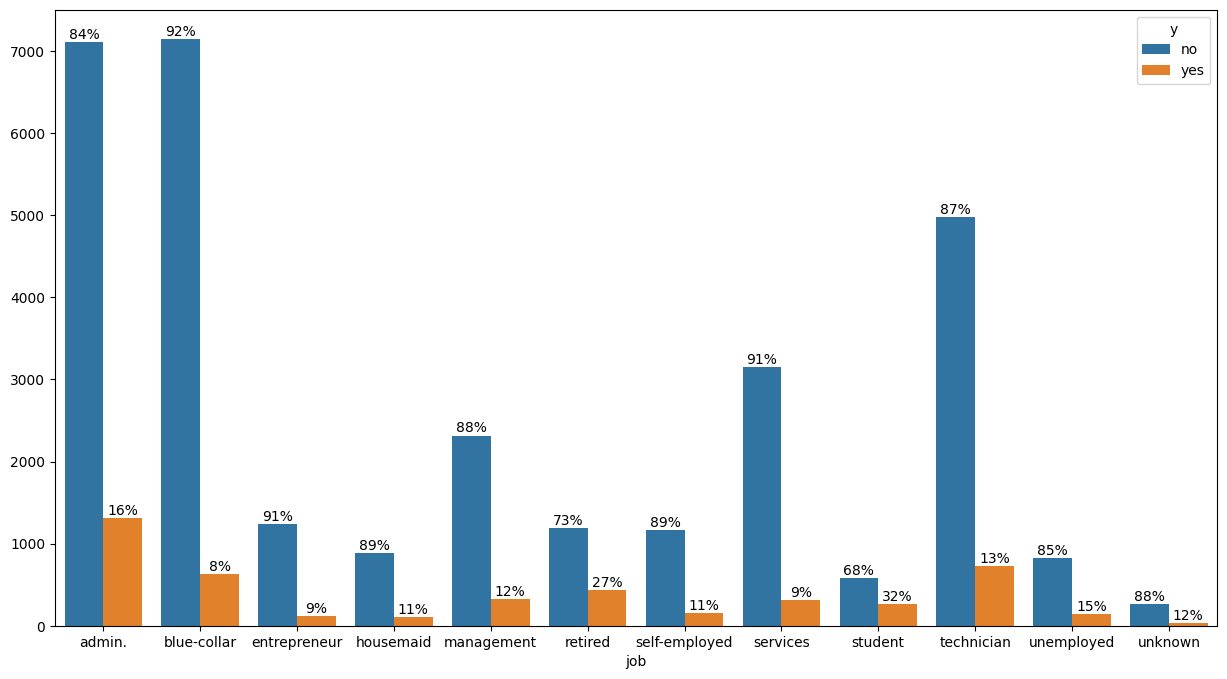

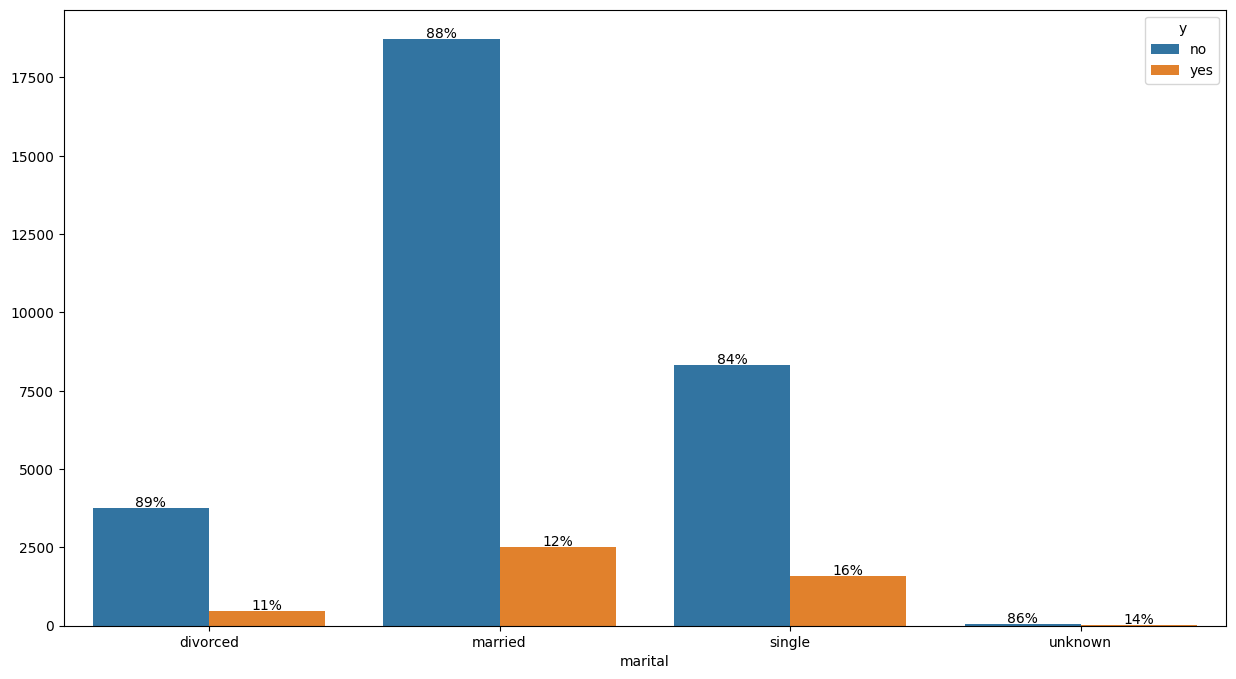

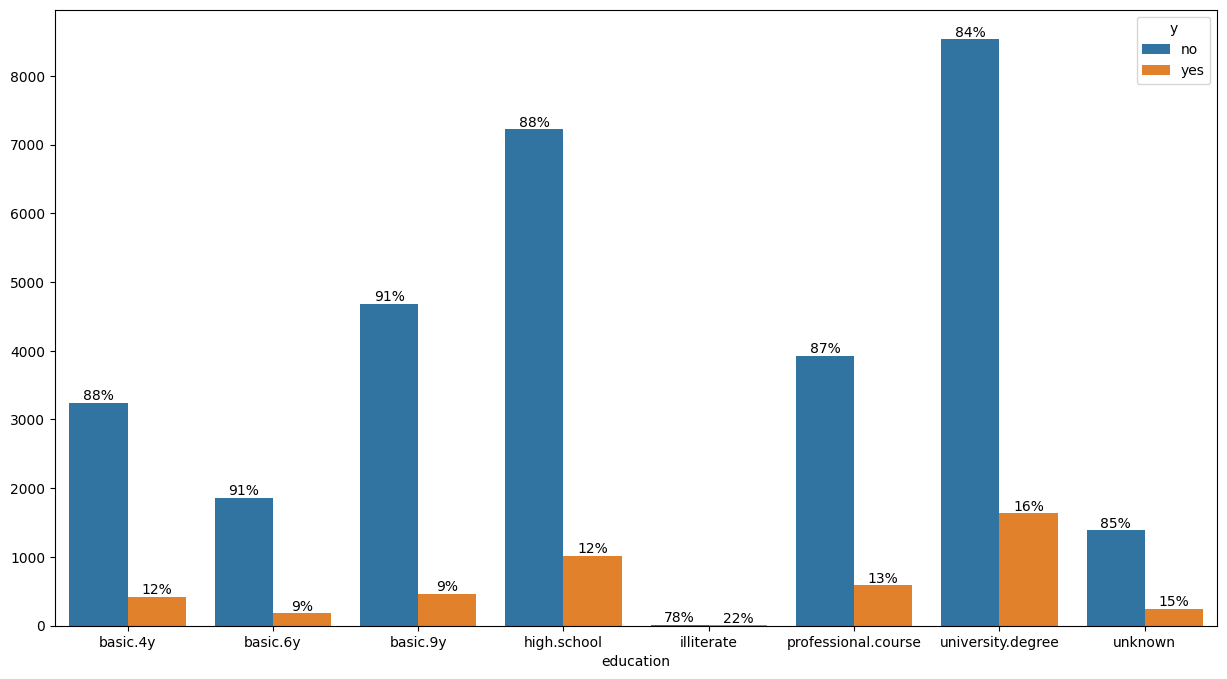

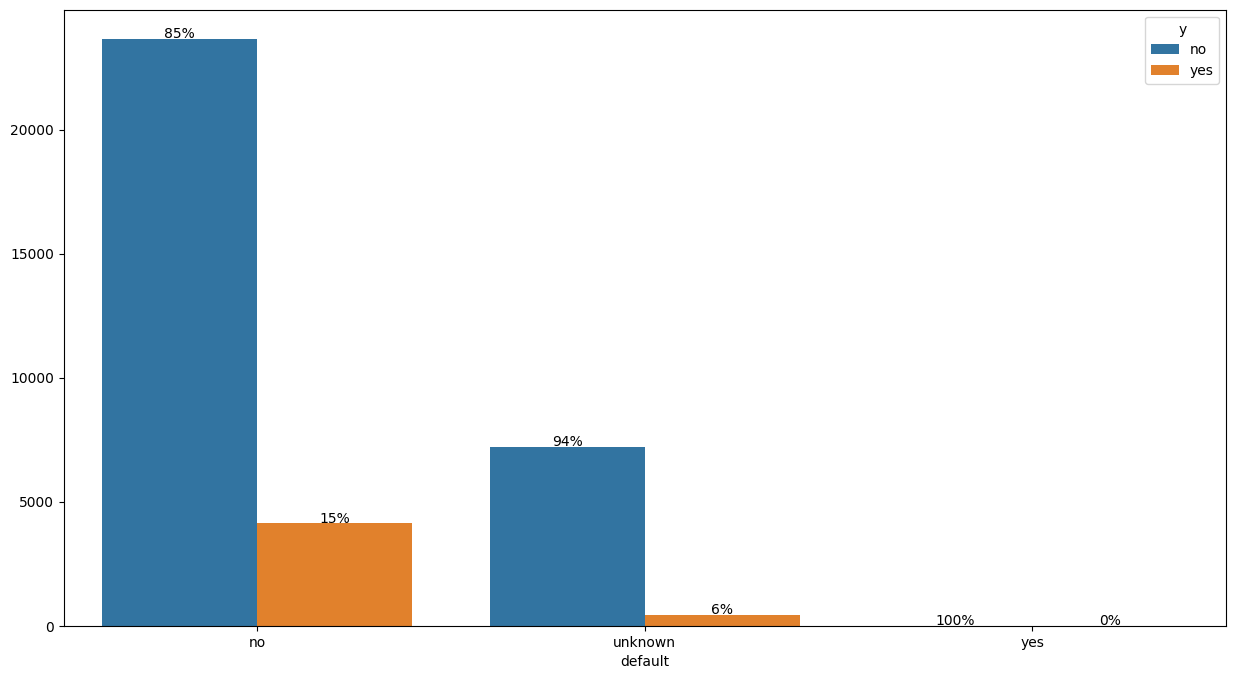

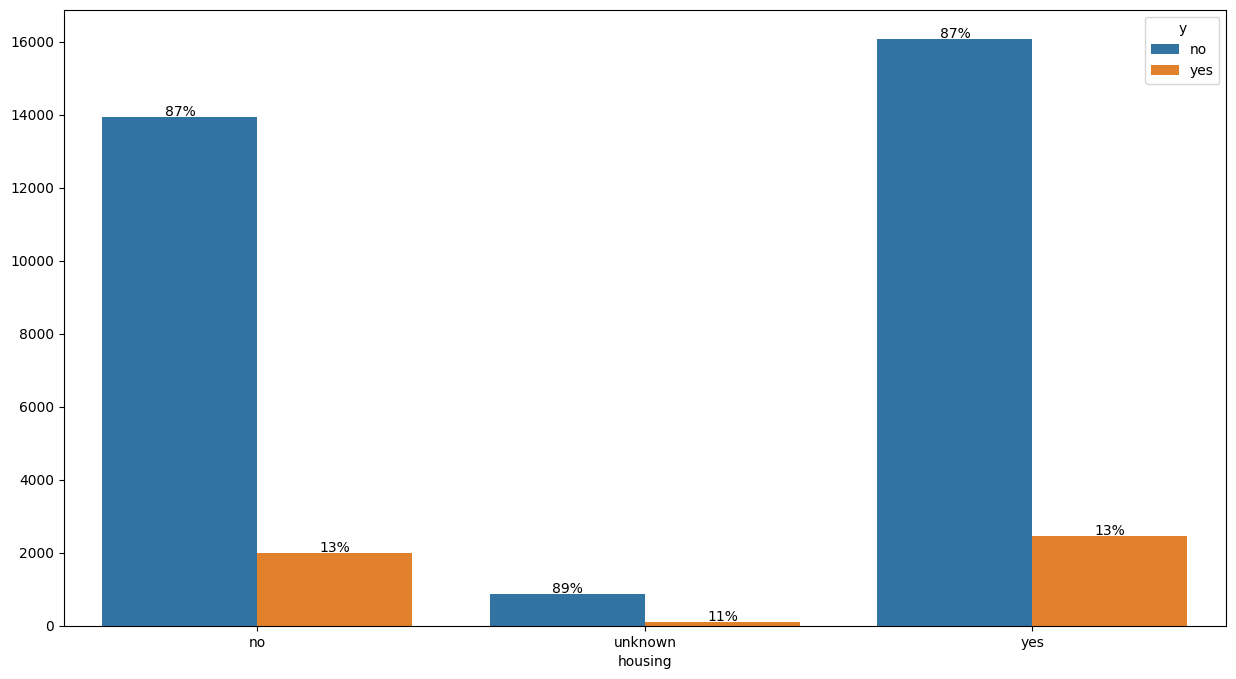

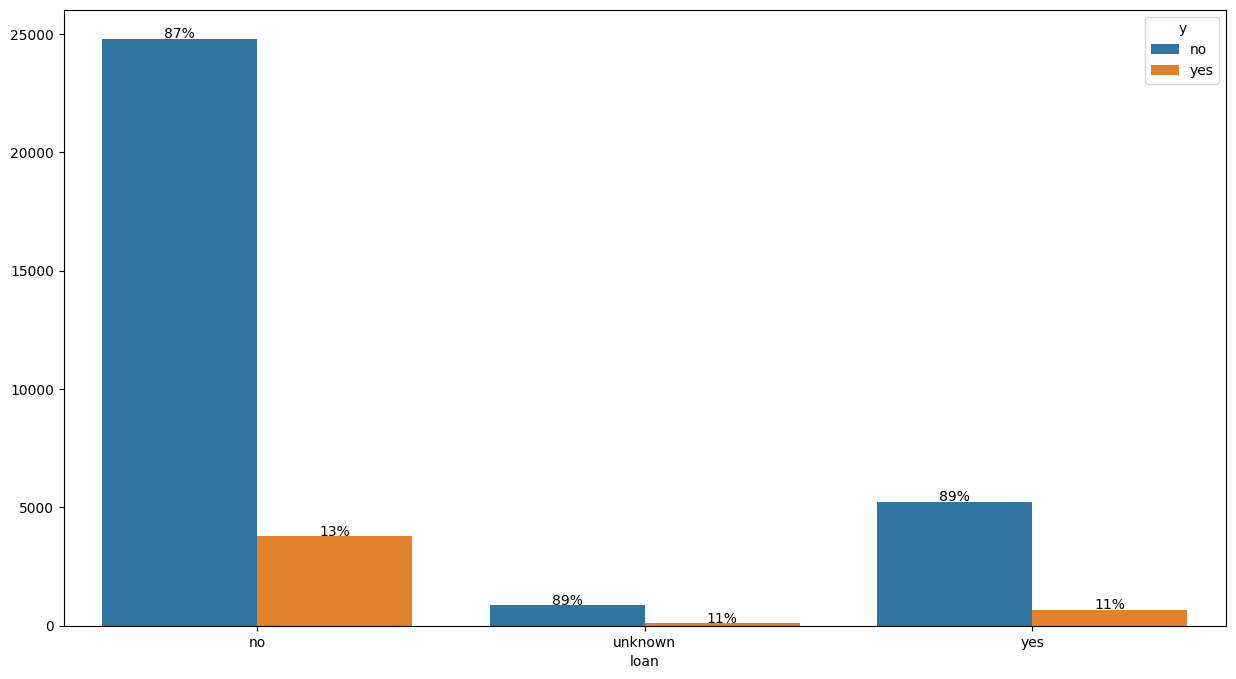

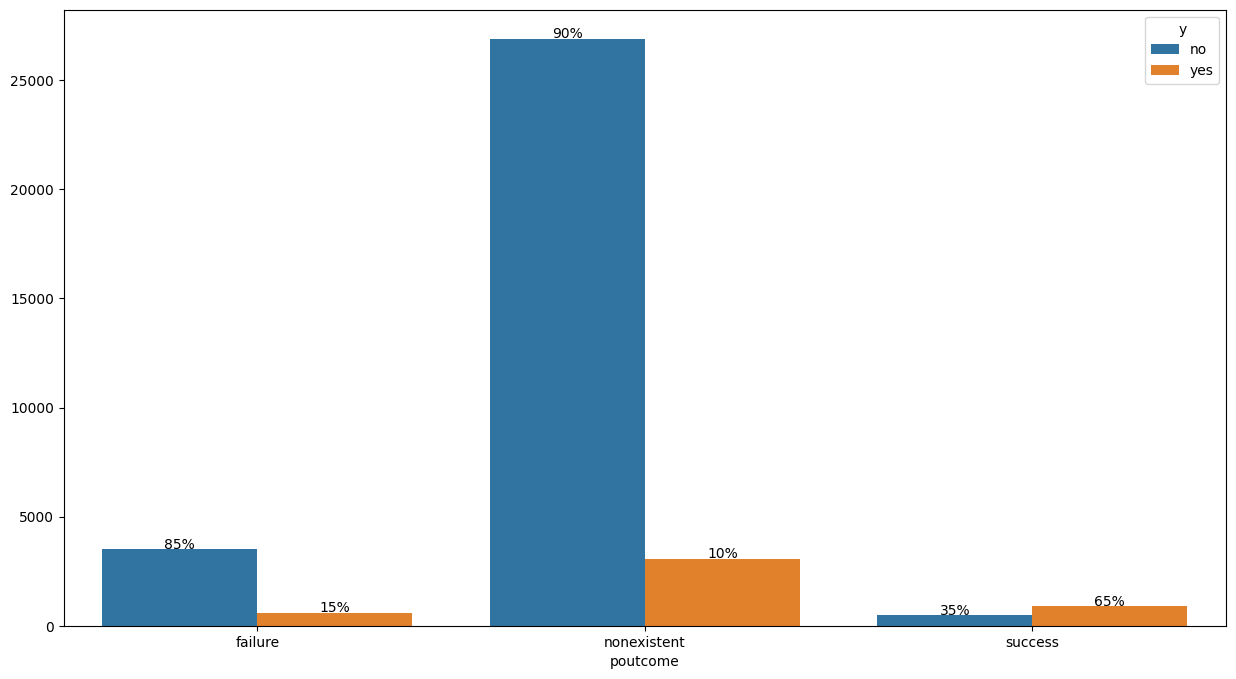

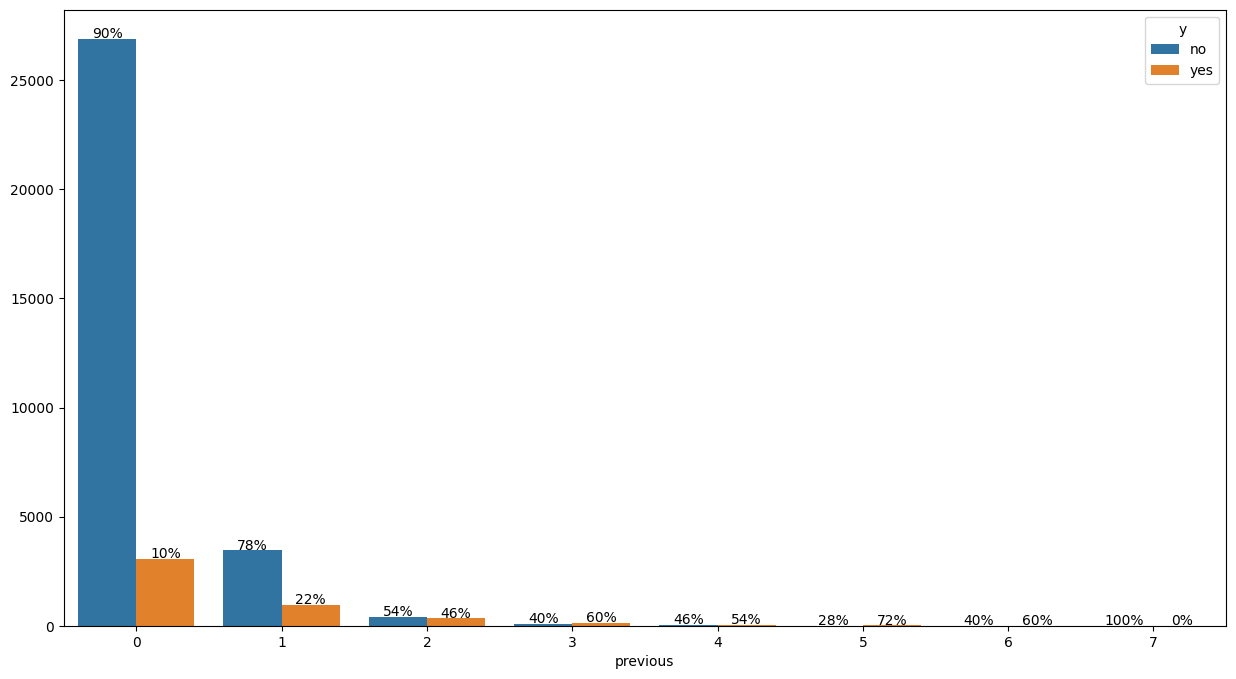

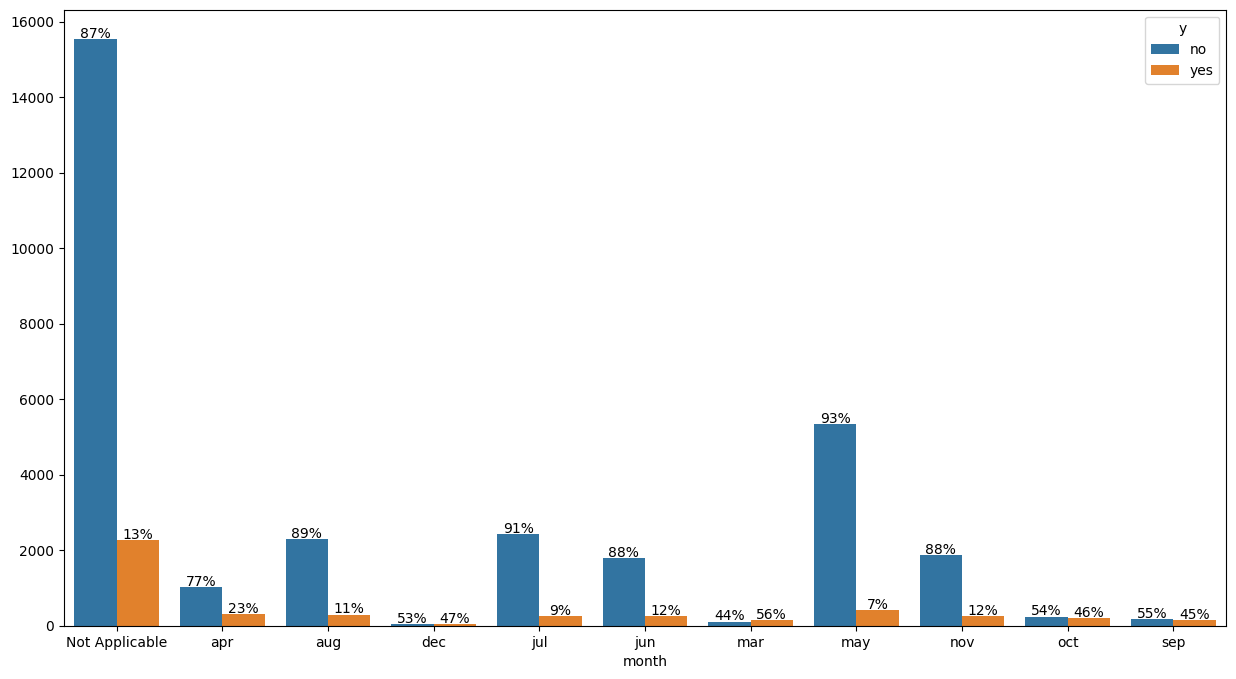

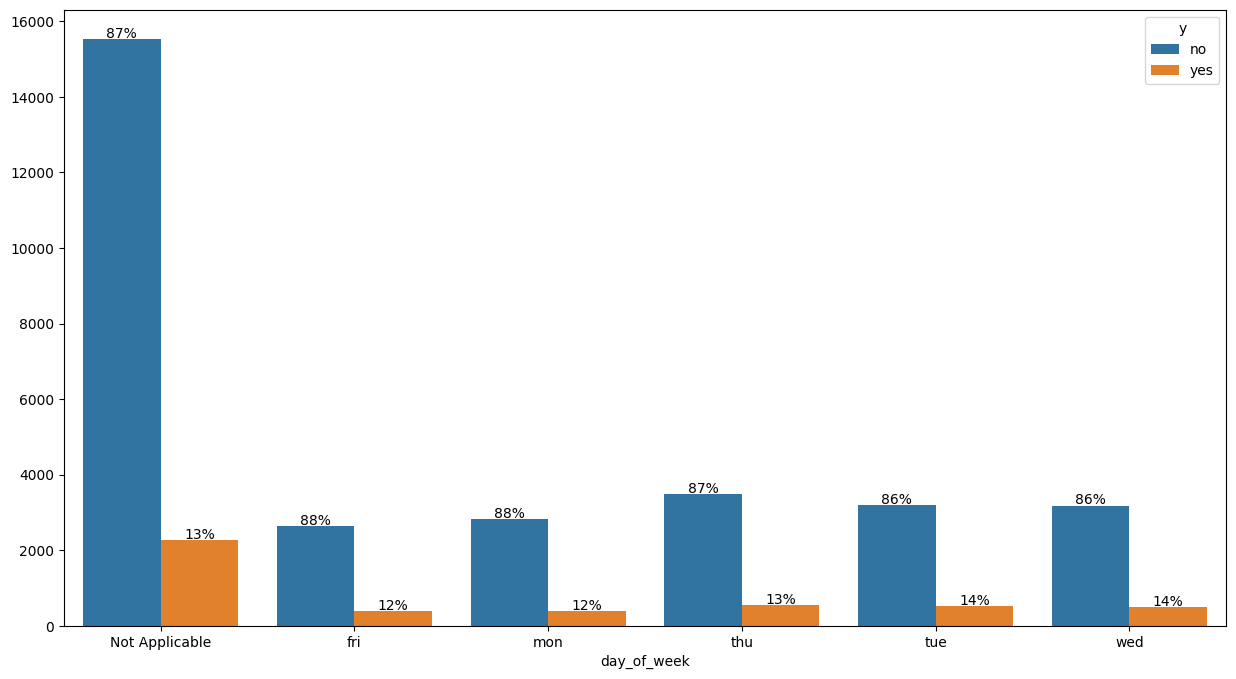

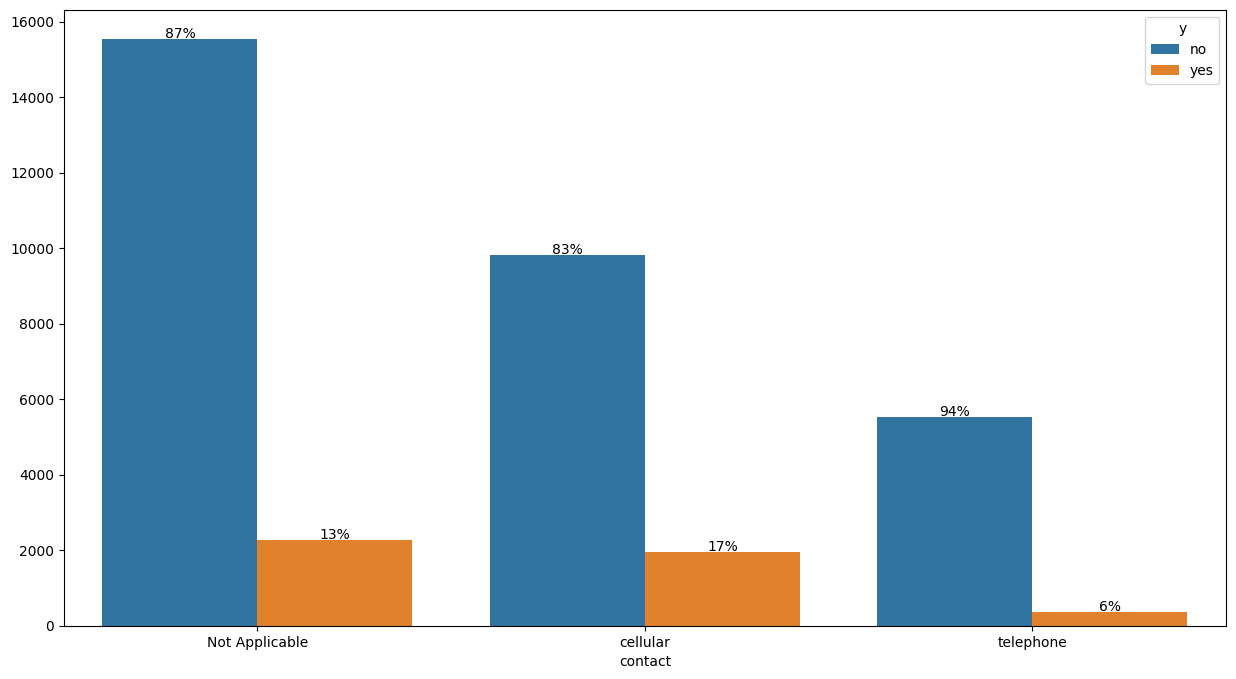

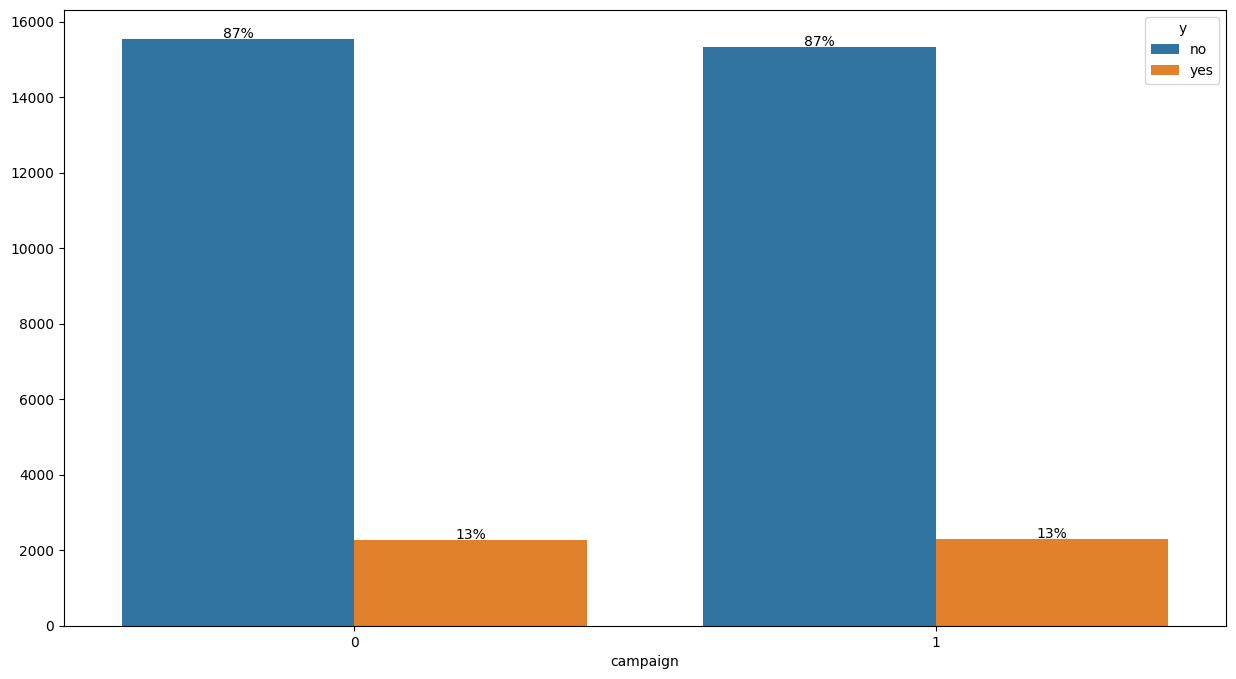

In [ ]:
def countplot(column, dataset,label):
    for index, category in enumerate(column):
        plt.figure(figsize=(15,8))
        order = sorted(dataset[category].unique())
        ax = sns.countplot(x= category, data=dataset, hue=label, order=order)
        ax.set_ylabel('')

        bars = ax.patches
        half = int(len(bars)/2)
        left_bars = bars[:half]
        right_bars = bars[half:]

        for left, right in zip(left_bars, right_bars):
            height_l = left.get_height()
            height_r = right.get_height()
            total = height_l + height_r

            ax.text(left.get_x() + left.get_width()/2., height_l + 40, '{0:.0%}'.format(height_l/total), ha="center")
            ax.text(right.get_x() + right.get_width()/2., height_r + 40, '{0:.0%}'.format(height_r/total), ha="center")

countplot(cat_features, campaign_data,'y')

绘制箱线图和分布图, 以理解数值特征对响应值的影响.

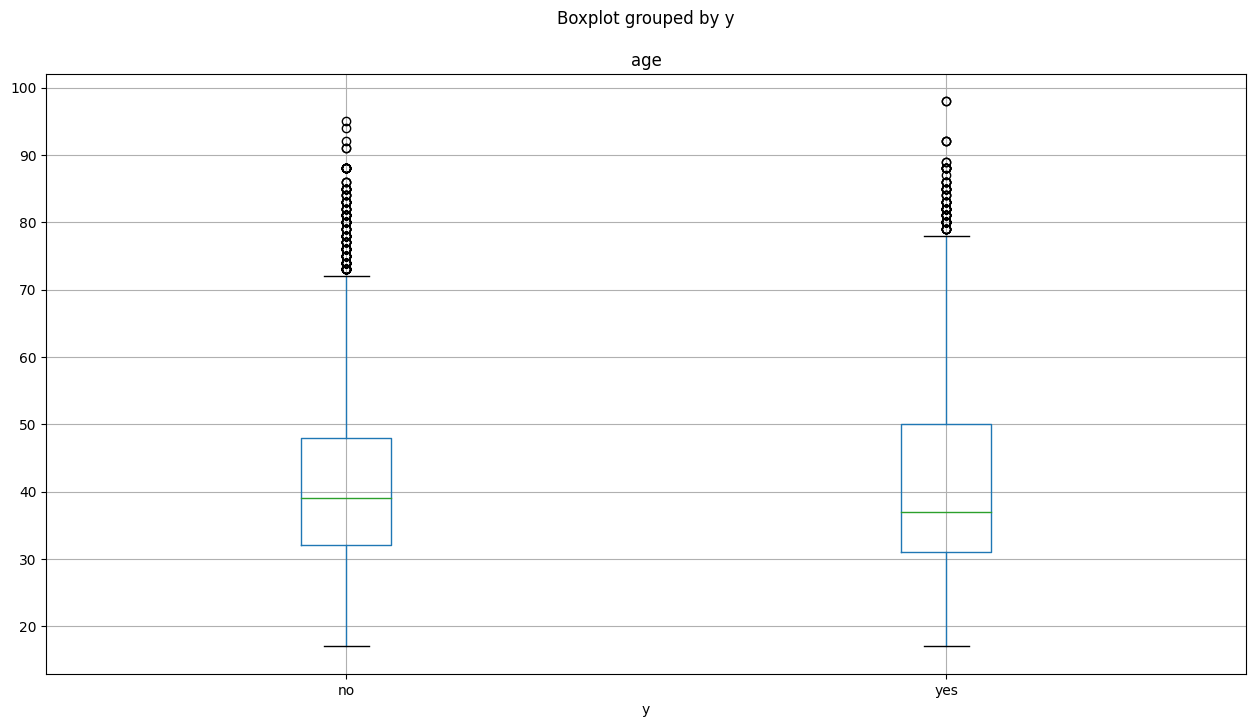

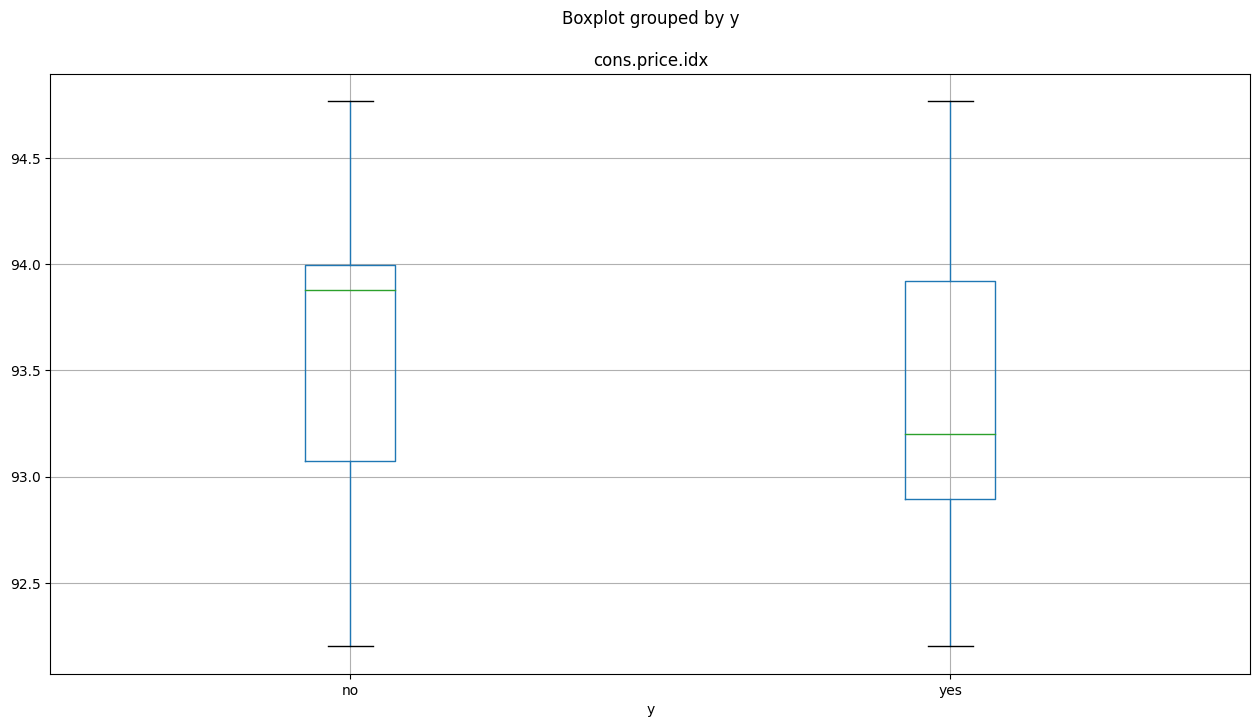

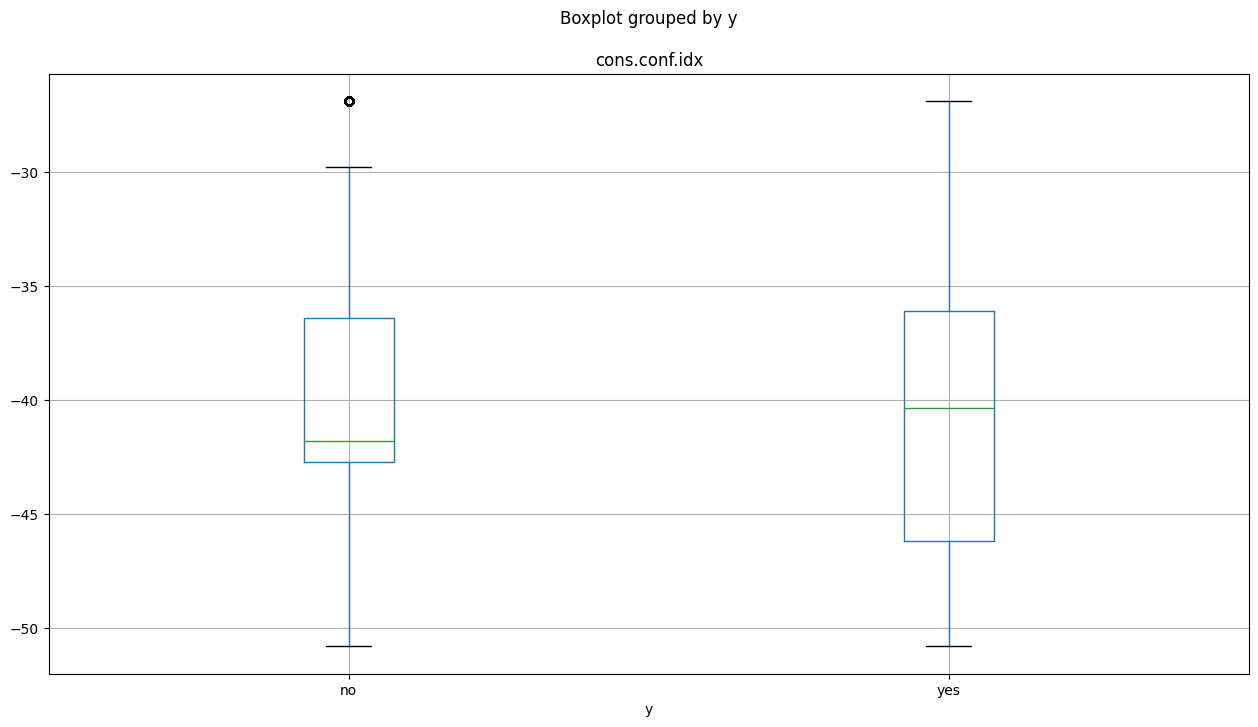

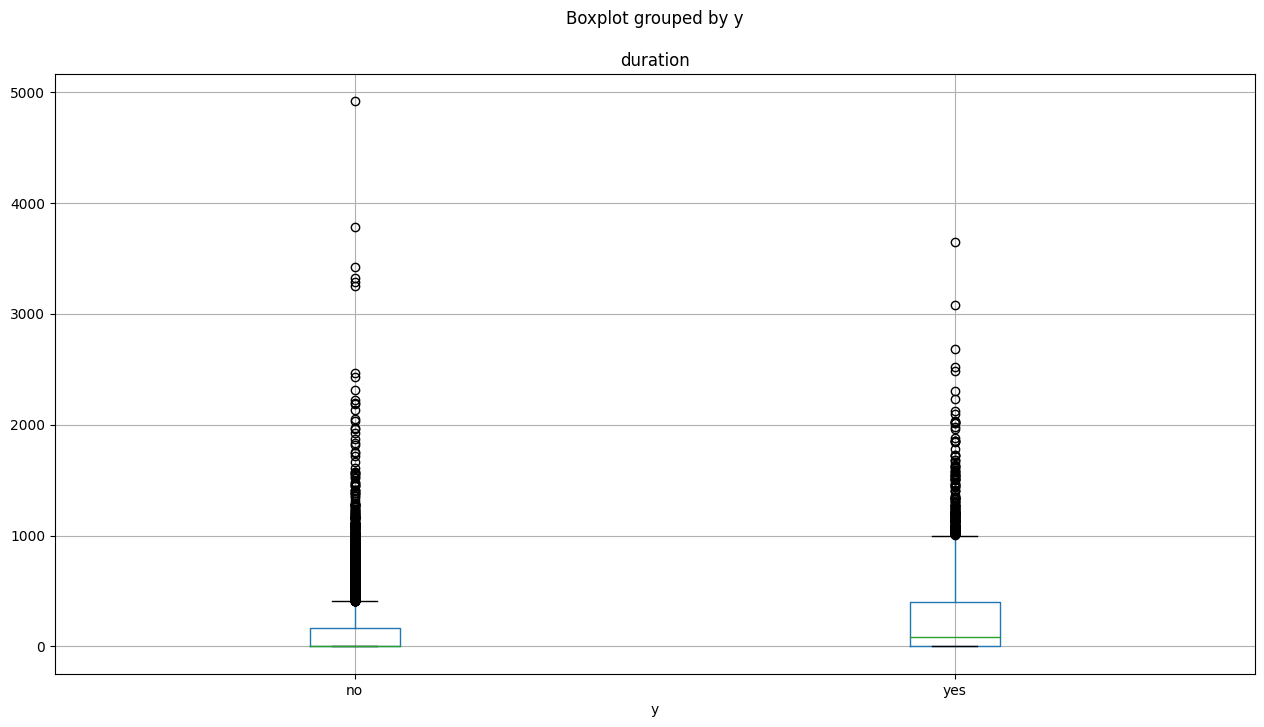

In [ ]:
def boxplot_response(columns,label,dataset):
    for c in columns:
        dataset.boxplot(by=label,figsize=(15,8),column=[c])
boxplot_response(num_features, 'y', campaign_data)

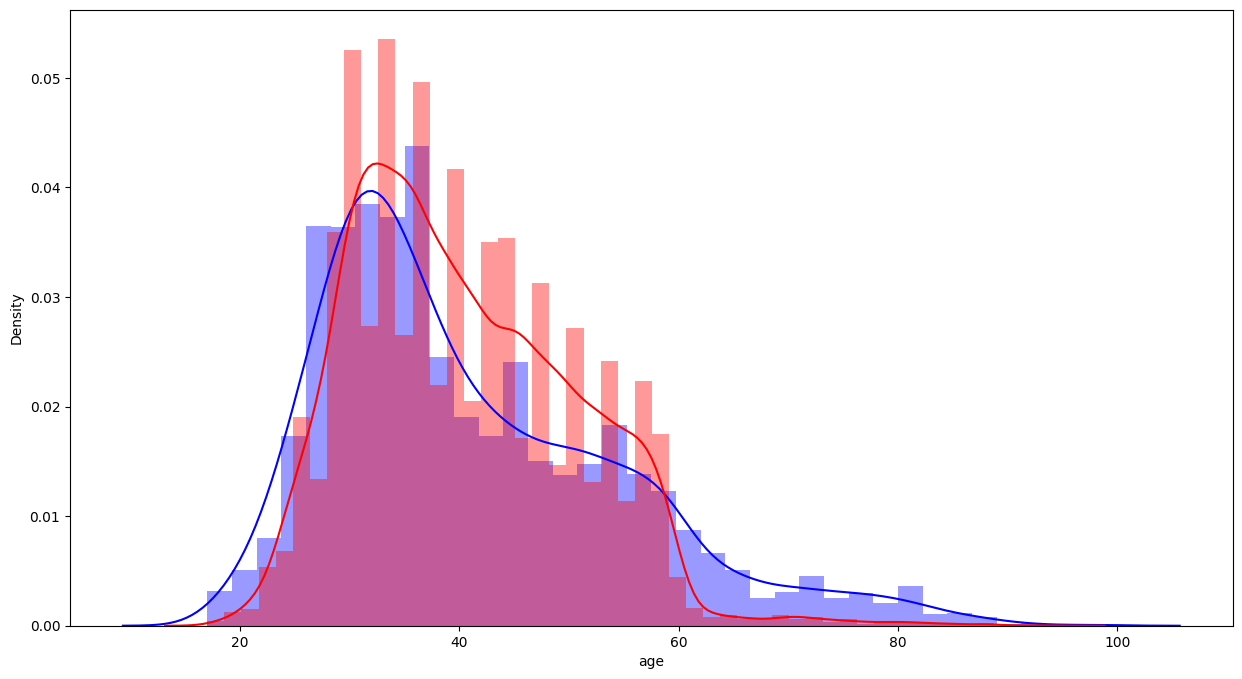

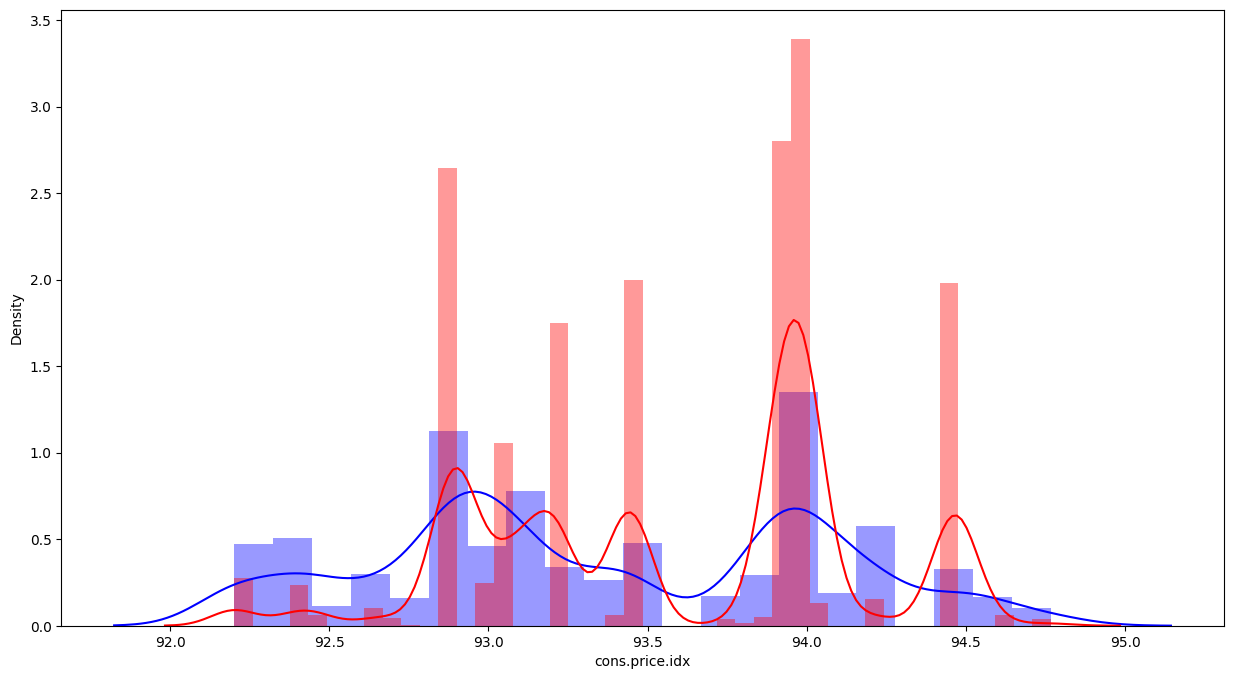

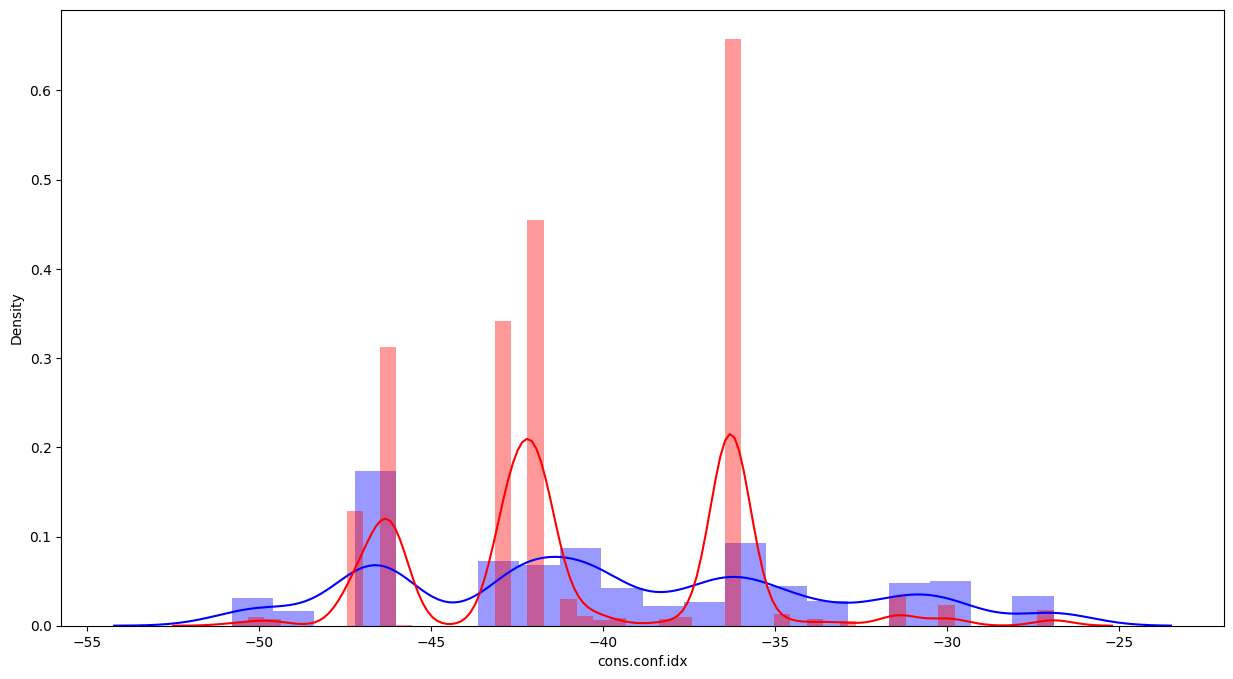

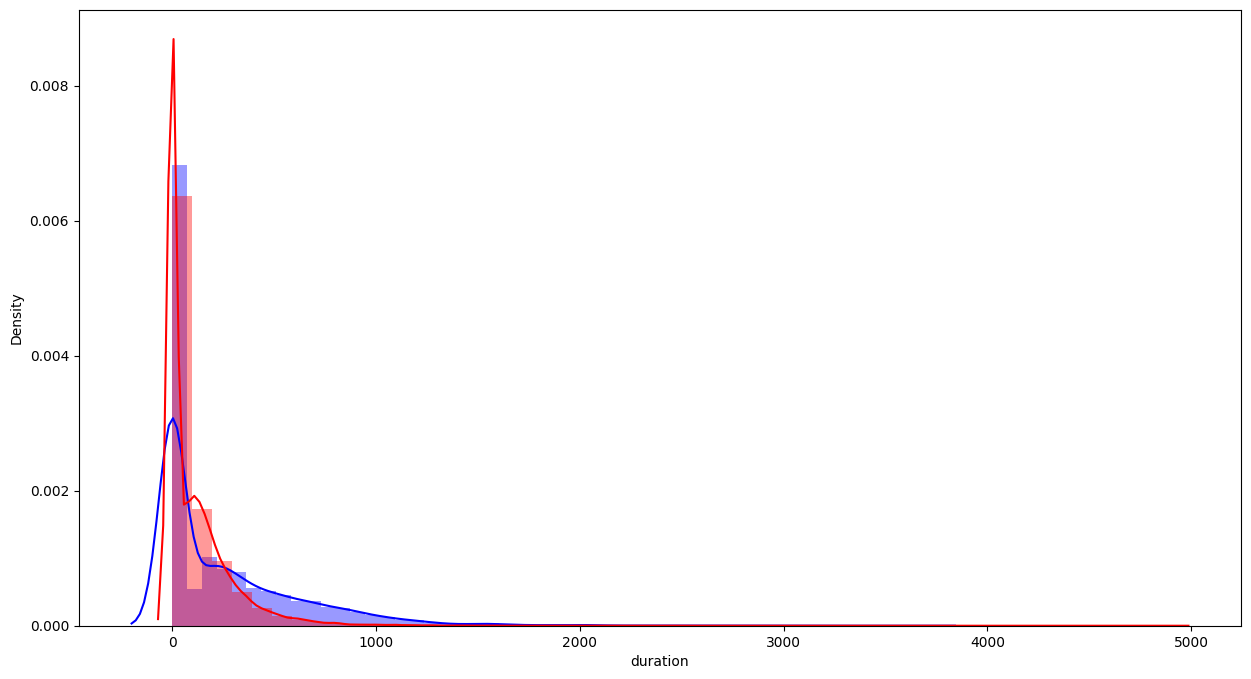

In [ ]:
def dsitplot_response(column, dataset):
    for c in column:
        plt.figure(figsize=(15,8))
        ax = sns.distplot(dataset.loc[(dataset['y']=='yes')][c],color='blue')
        ax = sns.distplot(dataset.loc[(dataset['y']=='no')][c], color='red')
#         plt.show()
dsitplot_response(num_features, campaign_data)

## 特征工程
针对数值特征, 我们执行两项主要变换:

- 对数值数据进行缩放, 使其均值和方差为 (0,1)
- 对 ***Duration*** 字段进行幂变换, 以消除偏度.

对于类别特征, 我们应用两项主要变换, 以获得更细粒度的分类特征:  
- 序数编码器(Ordinal Encoder)
- 独热编码器(One-hot Encoder)

In [ ]:
df_data = campaign_data.copy(deep=True)
train_data, test_data = train_test_split(df_data, test_size=0.4, random_state=RANDOM_SATE)

In [ ]:
from sklearn.preprocessing import power_transform, StandardScaler

def feature_transform(columns, dataset, method):
    new_features=[]
    scalers = {}
    for c in columns:
        if method == 'pwr':
            dataset[c+'_tfm']=power_transform(dataset[[c]]).reshape(-1,1)
            new_features.append(c+'_tfm')
            scaler = None
        if method == 'std':
            scaler = StandardScaler()
            scaler.fit(dataset[[c]])
            scalers[c]= scaler
            dataset[c+'_scl']= scaler.transform(dataset[[c]]).reshape(-1,1)
            new_features.append(c+'_scl')
    return new_features, scalers, dataset

在训练数据上拟合缩放器和幂变换器

In [ ]:
num_features_tfm, _ , train_data = feature_transform(['duration'], train_data, 'pwr')
num_features_scl, std_scaler, train_data = feature_transform(num_features, train_data, 'std')

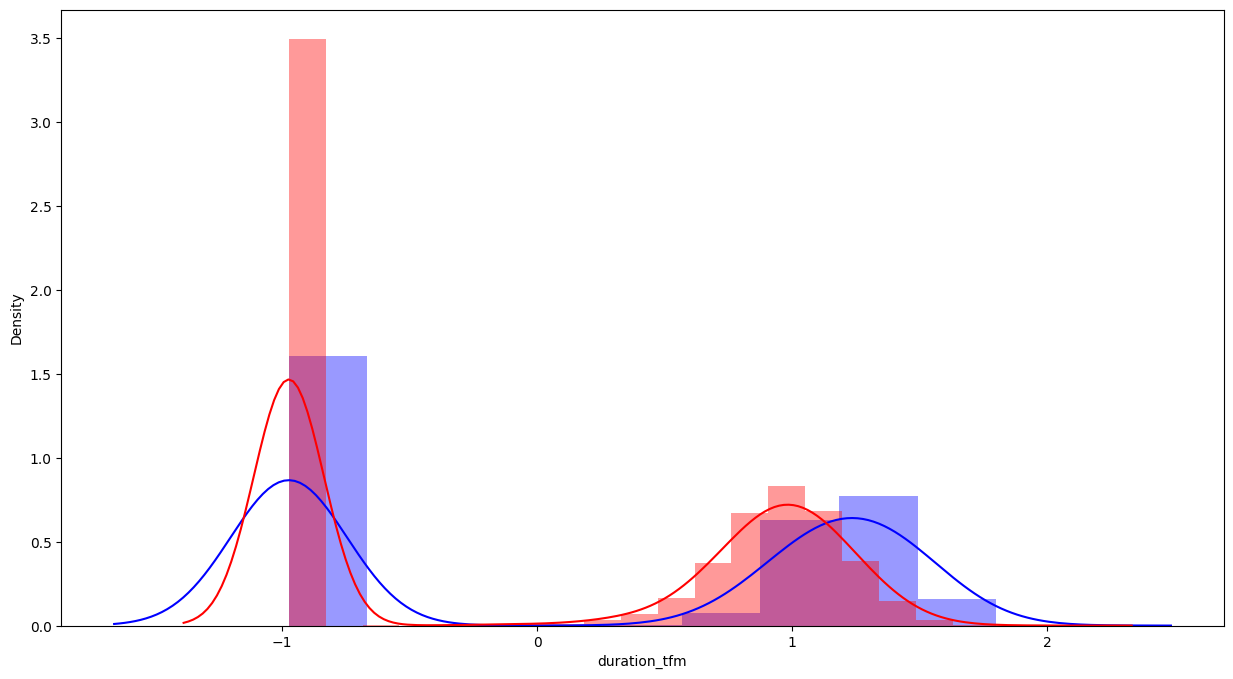

In [ ]:
dsitplot_response(num_features_tfm, train_data)

在测试数据上应用缩放器

In [ ]:
_,_,test_data = feature_transform(['duration'], test_data, 'pwr')
for c in num_features:
    test_data[c+'_scl'] = std_scaler[c].transform(test_data[[c]]).reshape(-1,1)

在训练数据上拟合序数编码器, 并应用到测试数据

In [ ]:
def encoder(dataset, columns):
    # label_encoder = LabelEncoder()
    # dataset['response'] = label_encoder.fit_transform(dataset['y'].to_numpy().reshape(-1,1))
    encoder_models = {}
    new_feature = []
    for c in columns:
        ord_encoder = OrdinalEncoder()
        ord_encoder.fit(dataset[c].to_numpy().reshape(-1,1))
        encoder_models[c]= ord_encoder
        dataset[c+'_int'] = encoder_models[c].transform(dataset[c].to_numpy().reshape(-1,1))
        new_feature.append(c+'_int')
    return encoder_models, new_feature, dataset

encoder_models, int_features, train_data = encoder(train_data, cat_features)
for c in cat_features:
    test_data[c+'_int'] = encoder_models[c].transform(test_data[c].to_numpy().reshape(-1,1))

对训练集和测试集中的目标变量应用标签编码器

In [ ]:
label_encoder = LabelEncoder()
train_data['response'] = label_encoder.fit_transform(train_data['y'].to_numpy().reshape(-1,1))
# TODO 2: use LabelEncode() function and transform test_data["response"]
# Edit the code by replacing the underscore
test_data['response'] = _____________________

在训练数据上拟合独热编码器, 并应用到测试数据

In [ ]:
def oh_encoder(dataset, features):
    ohe_models={}
    new_features=[]
    for c in features:
        oh_encoder=OneHotEncoder(handle_unknown='ignore')
        oh_encoder.fit(dataset[c].to_numpy().reshape(-1,1))
        out = oh_encoder.transform(dataset[c].to_numpy().reshape(-1,1))
        df= pd.DataFrame.sparse.from_spmatrix(out, columns=[c+'_'+n for n in oh_encoder.categories_[0]],)
        dataset = pd.concat([dataset,df.set_index(dataset.index)], axis=1)
        ohe_models[c]=oh_encoder
        new_features.extend([c+'_'+n for n in oh_encoder.categories_[0]])
    return ohe_models, new_features, dataset

In [ ]:
oh_models, oh_features, train_data = oh_encoder(train_data, cat_features)
for c in cat_features:
    out = oh_models[c].transform(test_data[c].to_numpy().reshape(-1,1))
    df= pd.DataFrame.sparse.from_spmatrix(out, columns=[c+'_'+n for n in oh_models[c].categories_[0]],)
    test_data = pd.concat([test_data,df.set_index(test_data.index)], axis=1)

## 二维可视化
很容易想到用 TSNE 来查看变换后的特征在二维空间中相对于响应值的表现.

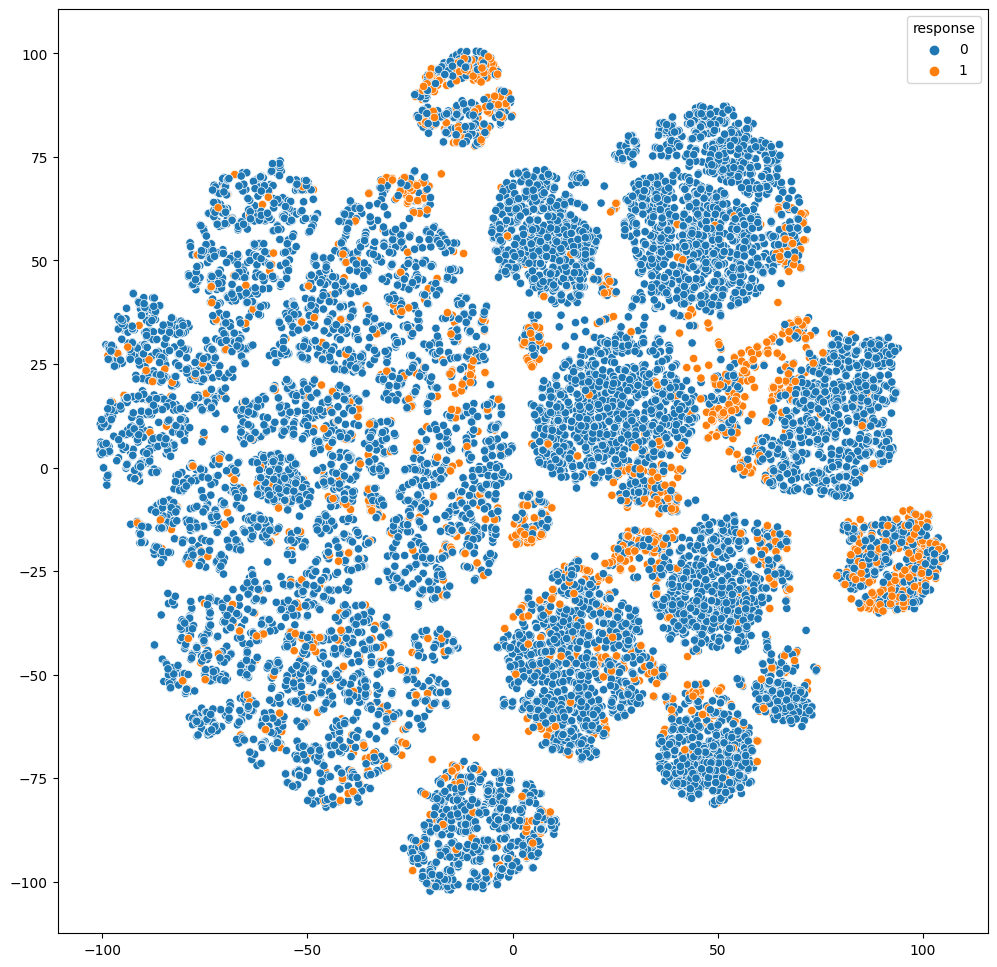

In [ ]:
tsne_model = TSNE(n_components=2,random_state=RANDOM_SATE, perplexity=30)
tnse_data = tsne_model.fit_transform(train_data[num_features_scl+
                                                num_features_tfm+
                                                oh_features])
plt.figure(figsize=(12,12))
sns.scatterplot(x=tnse_data[:,0], y=tnse_data[:,1], hue=train_data['response'])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

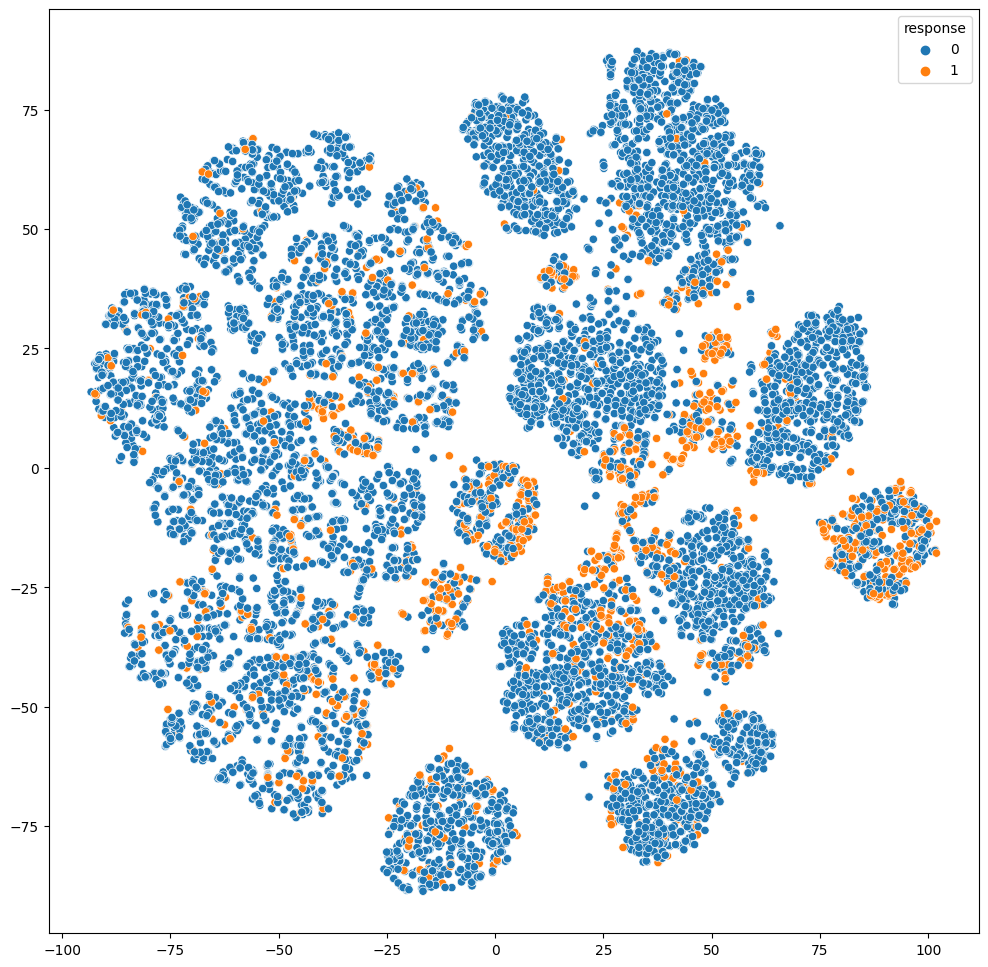

In [ ]:
tsne_model = TSNE(n_components=2,random_state=RANDOM_SATE, perplexity=30)
tnse_data = tsne_model.fit_transform(test_data[num_features_scl+
                                                num_features_tfm+
                                                oh_features])
plt.figure(figsize=(12,12))
sns.scatterplot(x=tnse_data[:,0], y=tnse_data[:,1], hue=test_data['response'])
plt.show

## 特征选择
### 单变量特征选择:
对类别特征使用以下两种方法进行特征选择, 以选出排名前 10 的显著预测变量:  
- Chi2(卡方检验)
- f_classif

In [ ]:
# TODO: Tech Focus Only:
# Add one or two other feature selection methods and present the feature importance

In [ ]:
def feature_selection_univariate(features, dataset, method, label,top_k):
    fselect_model = SelectKBest(method,k='all').fit(dataset[features],dataset[label])
    importances = fselect_model.scores_
    indices = np.argsort(importances)[-top_k:]
    selected_features =[features[i] for i in reversed(indices)]
    return fselect_model, selected_features

def plot_feature_importance(fselect_model, features):
    importances = fselect_model.scores_
    p_value = fselect_model.pvalues_
    indices = np.argsort(importances)[-10:]
    plt.figure(figsize=(15,8))
    plt.title('Feature Importances')
    plt.barh(range(len(indices)), importances[indices], color='blue', align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Relative Importance')
    for i, v in enumerate(indices):
        plt.text(importances[v]+3, i, str(p_value[v]), color='black', fontweight='bold')
    plt.show()

In [ ]:
features = int_features + oh_features
fselect_model_f_classif, selected_features_f_classif = feature_selection_univariate(
    features, train_data,f_classif,'response',10)
fselect_model_chi2, selected_features_chi2, = feature_selection_univariate(
    features, train_data,chi2,'response',10)

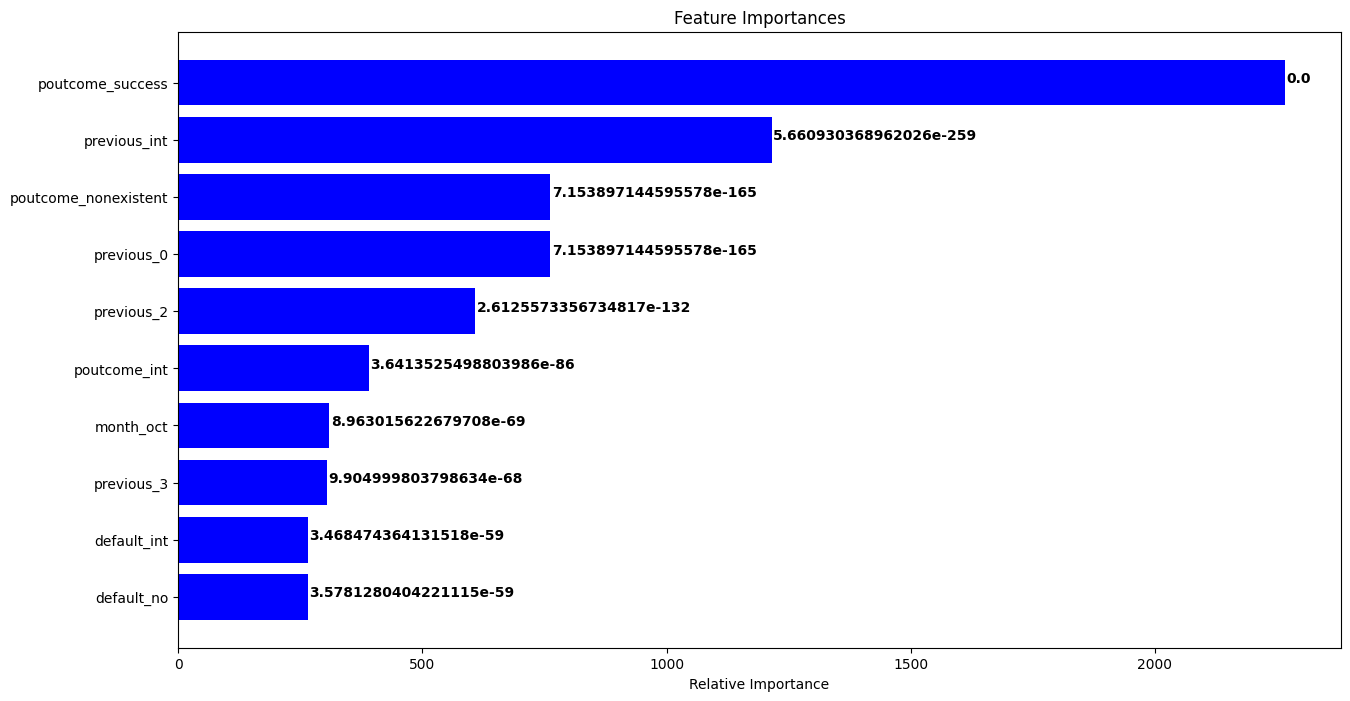

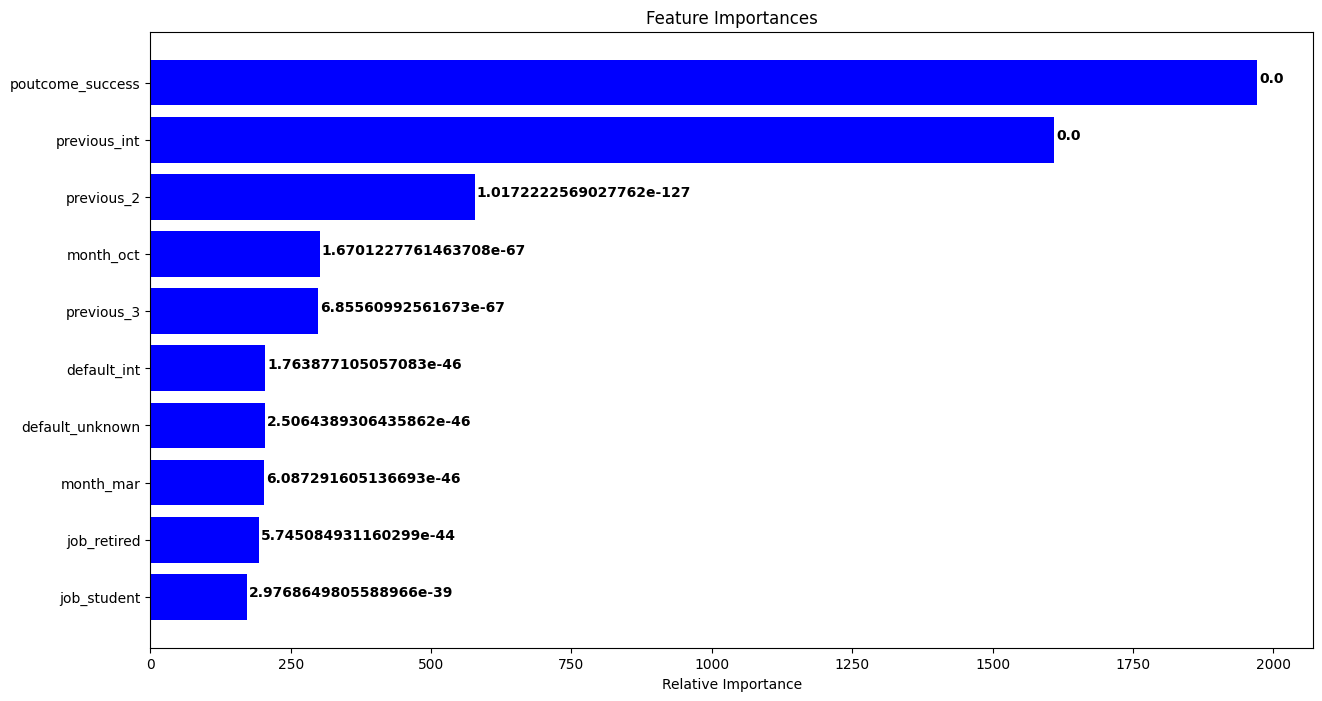

In [ ]:
plot_feature_importance(fselect_model_f_classif, features)
plot_feature_importance(fselect_model_chi2, features)

可以看出, 这两种方法各自选出的排名前 10 的特征, 都对响应值预测有显著贡献(**p 值小于 0.01**).

### 基于机器学习模型的特征选择
使用能够提供特征重要性的机器学习模型进行特征选择. 同时绘制所选特征之间的相关性图, 以确保特征之间不存在高度相关性. 用于特征选择的模型如下:
- 随机森林分类器(Random Forest Classifier)
- XGBoost 分类器
- 逻辑回归分类器

In [ ]:
def feature_selection_model(dataset, features, label, model, k):
    X = np.asarray(dataset[features])
    y = np.asarray(dataset[label])
    if model=='RF':
        clf = RandomForestClassifier(n_estimators=50,
                                     class_weight='balanced',
                                     random_state=RANDOM_SATE,
                                     n_jobs=8)
    elif model=='GB':
        clf = XGBClassifier(n_estimators=50,
                            scale_pos_weight=87,
                            random_state=RANDOM_SATE,
                            n_jobs=8)
    elif model =='LR':
        clf = LogisticRegression(C=1000,
                                 class_weight='balanced',
                                 max_iter=10000,
                                 n_jobs=8)
    else :
        print('please prvide proper model such as RF or GB or LR ')
    rfe = RFE(clf, n_features_to_select=k)
    rfe_model = rfe.fit(X, y)
    feature_list = {}
    for i, v in zip(features, rfe_model.ranking_):
        feature_list[i]=v
    selected_features = {k:v for k,v in feature_list.items() if v<=1}
    return selected_features

{'duration_tfm': 1, 'age_scl': 1, 'cons.price.idx_scl': 1, 'cons.conf.idx_scl': 1, 'duration_scl': 1, 'job_int': 1, 'education_int': 1, 'poutcome_int': 1, 'month_int': 1, 'poutcome_success': 1}


<Axes: >

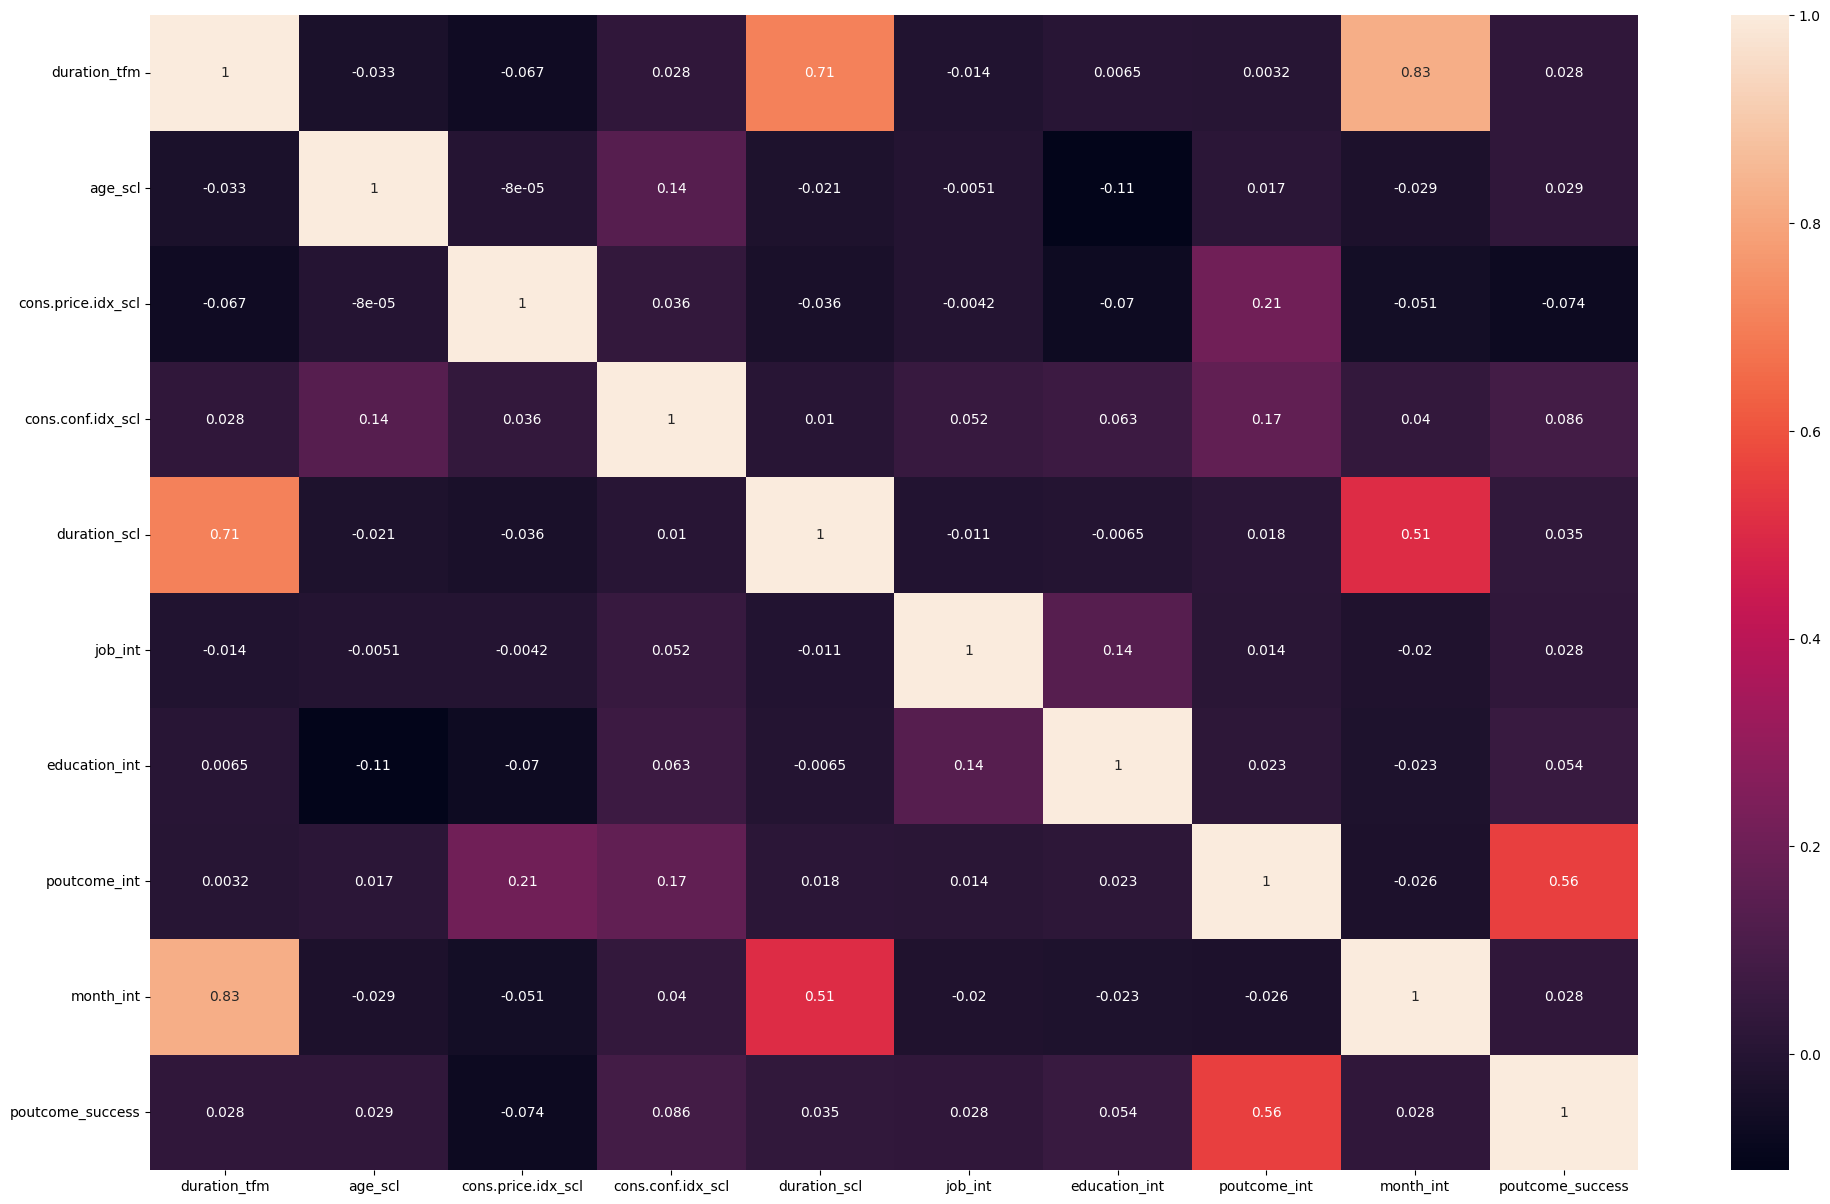

In [ ]:
selected_feature_RF = feature_selection_model(dataset=train_data,
                   features=num_features_tfm+num_features_scl+int_features+oh_features,
                   label='response',
                   model='RF',
                   k=10)
print(selected_feature_RF)
plt.figure(figsize=(24,15))
sns.heatmap(train_data[selected_feature_RF].corr(), annot=True)

In [ ]:
# TODO 3: run featuer selection using feature_selection_model() and logistic Regresion ('LR')
#[Similar to above code block that used Random Forest ('RF')]
# Edit the code by replacing the underscore

{'duration_tfm': 1, 'campaign_int': 1, 'default_yes': 1, 'poutcome_success': 1, 'previous_7': 1, 'month_mar': 1, 'month_oct': 1, 'contact_Not Applicable': 1, 'campaign_0': 1, 'campaign_1': 1}


<Axes: >

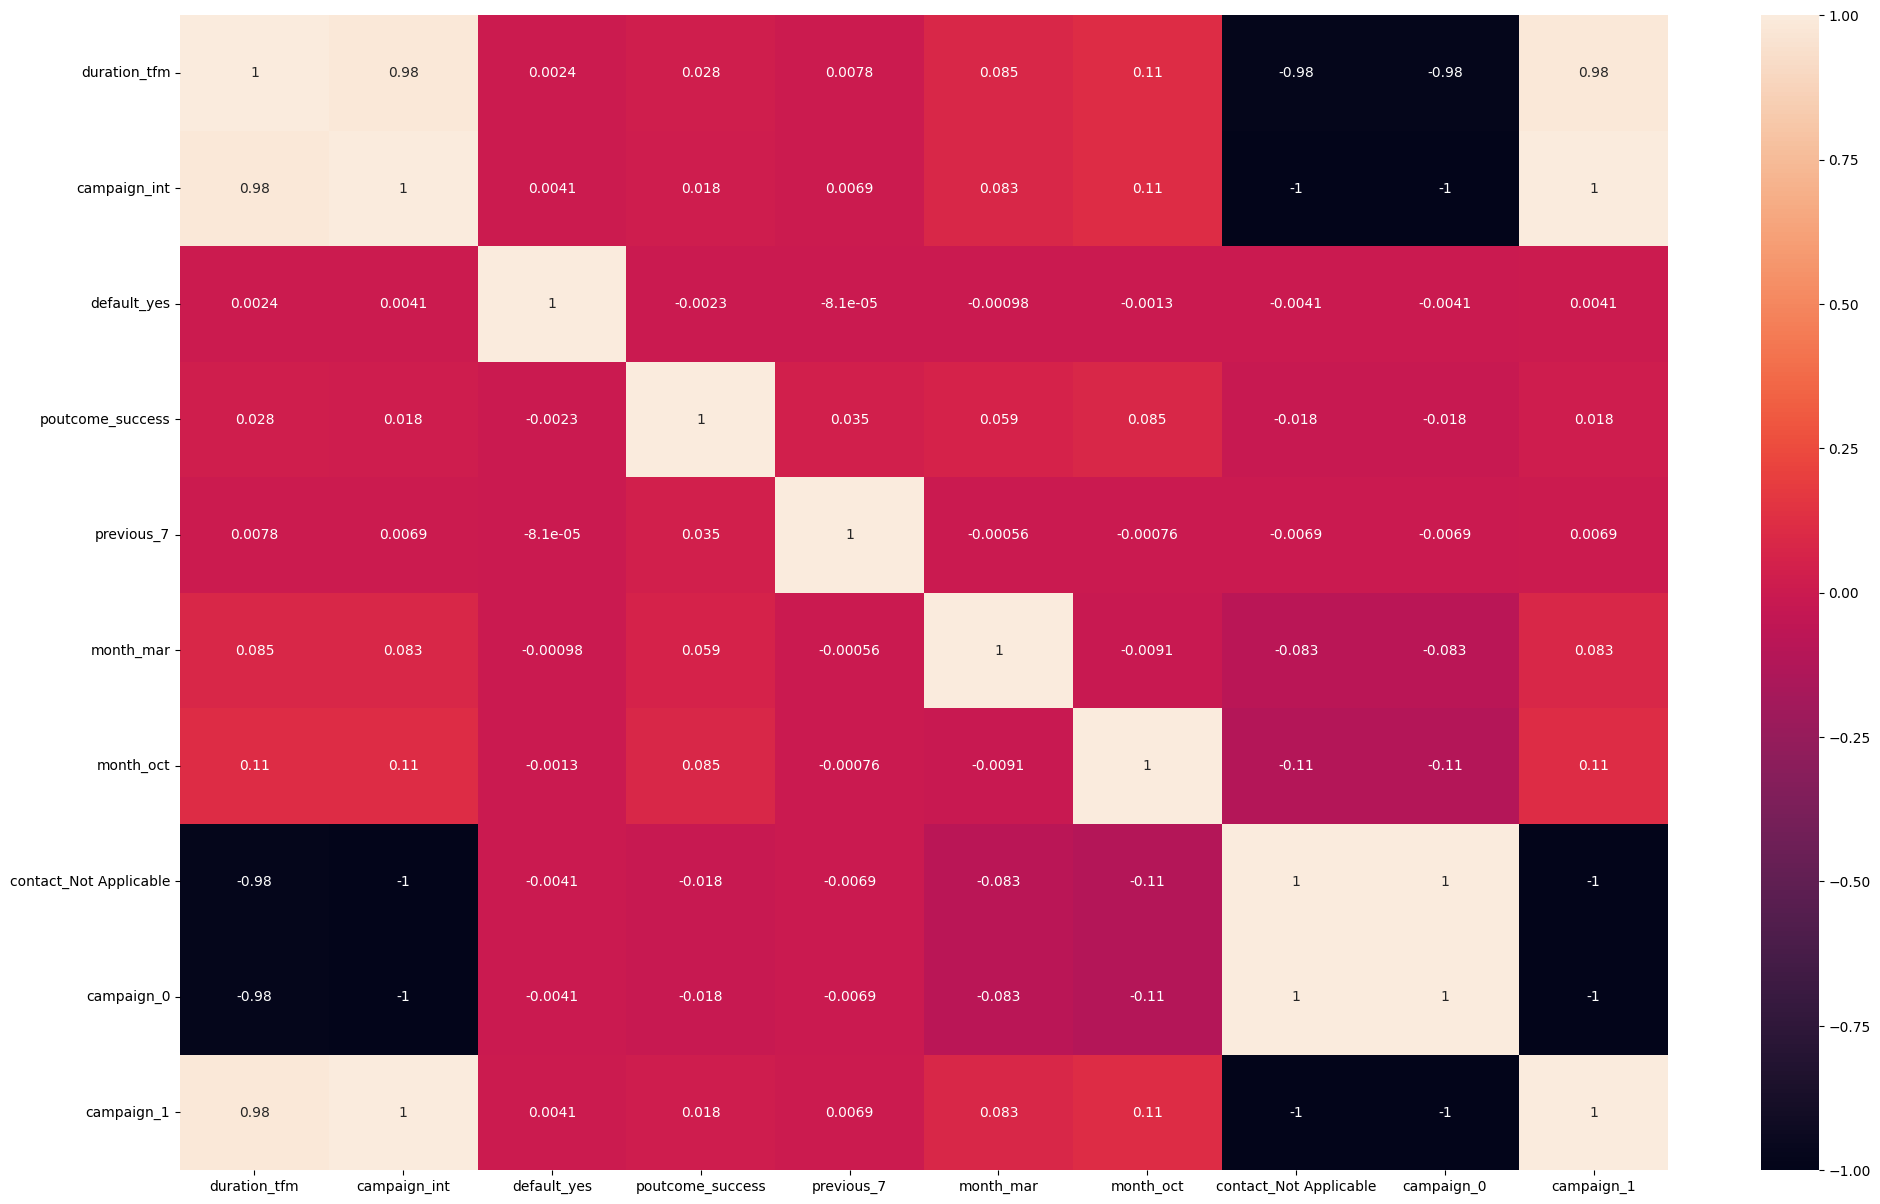

In [ ]:
selected_feature_LR = feature_selection_model(dataset=train_data,
                   features=num_features_tfm+num_features_scl+int_features+oh_features,
                   label=_______,
                   model=_____,
                   k=____)
print(selected_feature_LR)
plt.figure(figsize=(24,15))
sns.heatmap(train_data[selected_feature_LR].corr(), annot=True)

In [ ]:
# TODO: Tech Focus Only:
# Evaluate the selected features from previous methods (univariate and model selected) and propose which
# features should be used in traning.

假设由随机森林(RF)选出的特征能提供更好的结果. 因此我们使用这些选定特征进行建模, 并在测试数据上比较结果. 使用 RF 和 XGB 进行建模, 是因为它们都能够处理复杂的模式. 此外, 它们还具有类别不平衡加权机制, 可以很好地处理不平衡问题.

In [ ]:
def modeling(train_data, test_data, selected_faeture):
    rf_parameters = {'max_depth':[5],
                     'criterion':['gini'] ,
                     'n_estimators':[100]}
    gb_parameters = {'learning_rate':[0.01],
                     'n_estimators':[100],
                     'max_depth':[5],
                     'colsample_bytree':[0.1],
                     'subsample':[0.1]}

    rf = RandomForestClassifier(random_state=RANDOM_SATE,
                                n_jobs=8,
                                class_weight='balanced')

    gb = XGBClassifier(random_state=RANDOM_SATE,
                       n_jobs=8,
                       scale_pos_weight=87)

    clf_rf = GridSearchCV(estimator=rf,
                          param_grid=rf_parameters,
                          scoring='roc_auc',
                          n_jobs=8,
                          verbose=10,
                          cv=5)
    clf_gb = RandomizedSearchCV(estimator=gb,
                                param_distributions=gb_parameters,
                                scoring='roc_auc',
                                n_iter=20,
                                n_jobs=8,
                                verbose=10,
                                cv=5)

    model_rf = clf_rf.fit(train_data[selected_faeture], train_data['response'])
    model_gb = clf_gb.fit(train_data[selected_faeture], train_data['response'])

    auc_score={}
    auc_score['rf'] = roc_auc_score(test_data['response'], model_rf.best_estimator_.predict(test_data[selected_faeture]))
    auc_score['gb'] = roc_auc_score(test_data['response'], model_gb.best_estimator_.predict(test_data[selected_faeture]))
    return model_rf, model_gb, auc_score

In [ ]:
rf, gb, auc_score = modeling(train_data, test_data, selected_feature_RF)
auc_score

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


{'rf': 0.7353483836367084, 'gb': 0.5}

In [ ]:
# TODO: Tech Focus Only:
# Add more hyperparameters to above models and iterate to see how the models behaviour
# and select the btter model.

从上面可以看出, RF 的表现优于 XGB. 因此我们在最终流程中采用 RF 模型以及由 RF 选出的特征集.

## 最终流程
借助 sklearn 的 pipeline, 将所有数据预处理和建模步骤整合到一个流程中. 该流程包括:
- 幂变换
- 标准缩放
- 独热编码
- 递归特征消除
- 通过交叉验证进行随机森林训练

In [ ]:
cat_features=['job', 'marital', 'education', 'default', 'housing','loan',
              'poutcome','previous','month','day_of_week','contact','campaign']
num_features=['age','cons.price.idx', 'cons.conf.idx','duration']

In [ ]:
df_data = campaign_data.copy(deep=True)
train_data, test_data = train_test_split(df_data, test_size=0.4, random_state=RANDOM_SATE)

*** 这可能需要一些时间 ***

In [ ]:
from sklearn.compose import ColumnTransformer
num_transformer = Pipeline(steps=[('power',PowerTransformer())])
num_scaler = Pipeline(steps=[('scaler', StandardScaler())])
cat_encoder = Pipeline(steps=[('order', OrdinalEncoder()),
                              ('ohe',OneHotEncoder(handle_unknown='ignore'))])
prep = ColumnTransformer(
            transformers=[('dur', num_transformer,['duration']),
                          ('scaler',num_scaler,['age','cons.price.idx', 'cons.conf.idx','duration']),
                          ('encoder',cat_encoder, cat_features)
                         ]
                        )

clf = RandomForestClassifier(n_estimators=50,
                             class_weight='balanced',
                             random_state=123,
                             n_jobs=8)
rfe = RFE(clf,n_features_to_select=10)

# TODO: add more hyper parameter valus for max_depth and n_estimators
# Edit the code by replacing the underscore

rf_parameters = {'max_depth':[3,5,___],
                 'criterion':['gini', 'entropy'] ,
                 'n_estimators':[100,200,___]
                }
rf = RandomForestClassifier(class_weight='balanced',
                            random_state=RANDOM_SATE,
                            n_jobs=8)
clf_cv = GridSearchCV(estimator=rf,
                      param_grid=rf_parameters,
                      scoring='roc_auc',
                      n_jobs=8,
                      verbose=10,
                      cv=5)

pipe= Pipeline(steps=[('prep',prep),
                      ('rfe' ,rfe),
                      ('clf' ,clf_cv)
                     ])

ml_pipe = pipe.fit(X=train_data, y=train_data['y'])

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [ ]:
dump(ml_pipe, 'ml_pipe.joblib')
print("AUC of model on Traning Data: "+ str(ml_pipe.score(X=train_data, y=train_data['y'])))
print("AUC of model on Test Data: "+ str(ml_pipe.score(X=test_data,   y=test_data['y'])))

AUC of model on Traning Data: 0.8431855326034238
AUC of model on Test Data: 0.8453910547031147


In [ ]:
# TODO: Tech Focus Only:
# Try other metrics than 'roc_auc'in the pipeline and compare the results

## 客户评分
对特征 "Duration" 进行变换, 并为时长创建 11 个区间


In [ ]:
duration_df = pd.DataFrame()
duration_df['duration'] = train_data['duration']
duration_df['tfm_duration']=PowerTransformer().fit_transform(train_data['duration'].to_numpy().reshape(-1,1))
duration_df['buk_duration']=KBinsDiscretizer(n_bins=11,
                                             encode='ordinal',
                                             strategy='uniform').fit_transform(duration_df['tfm_duration'].to_numpy().reshape(-1,1))
duration = dict(duration_df.groupby(['buk_duration'])['duration'].mean().round())
print(duration)

{0.0: 0.0, 1.0: 1.0, 2.0: 5.0, 3.0: 8.0, 4.0: 19.0, 5.0: 41.0, 6.0: 88.0, 7.0: 188.0, 8.0: 416.0, 9.0: 936.0, 10.0: 2474.0}


计算在每个时长区间内响应为正的概率, 并最终为一批客户样本计算分数

In [ ]:
sample_customer = pd.DataFrame()
sample_customer = test_data.sample(n=200, random_state=143)
sample_customer['original_duration']= sample_customer['duration']
for k, v in duration.items():
    sample_customer['duration']= duration[k]
    sample_customer['pr'+str(int(k))]= ml_pipe.predict_proba(X=sample_customer)[:,1]

sample_customer['score'] = sum([200*sample_customer['pr'+str(int(k))] if k==0 else
                                (100-k*2)*sample_customer['pr'+str(int(k))]
                                for k, v in duration.items()])/11

In [ ]:
sample_customer.sort_values(["score"], ascending=False)

## 聚类分析(可选)
我们使用所选特征进行简要的聚类分析, 以获取关于客户及其在不同聚类中的模式的有用信息. 我们希望看看是否能够以有意义的方式对客户进行细分.  

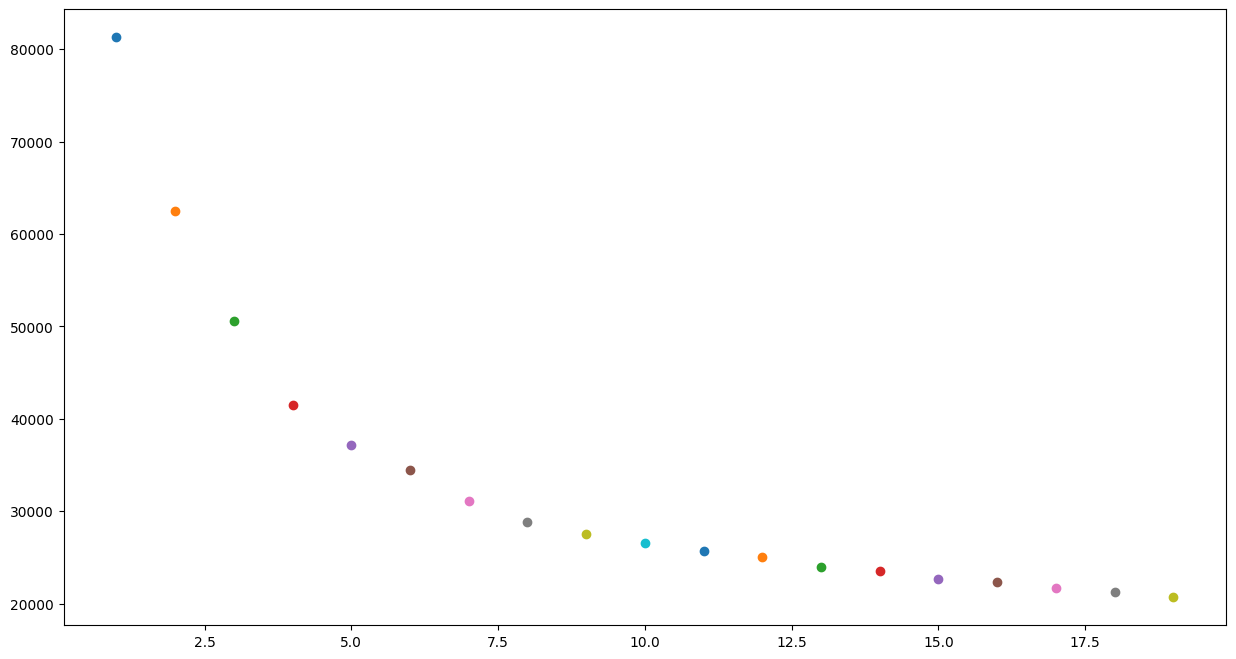

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.cluster import KMeans
cluster_data = train_data.copy(deep=True)
rss = {}

for k in range(1,20):
    kmeans = KMeans(n_clusters=k).fit(
        ml_pipe.steps[1][1].transform(ml_pipe.steps[0][1].transform(train_data))[:,(1,2,3,5,6,7,8,9)]
    )
    rss[k] = kmeans.inertia_
plt.figure(figsize=(15,8))
for k in rss:
    plt.scatter(int(k), rss[k])
plt.savefig('test.png')

In [ ]:
cluster_data['cluster'] = KMeans(n_clusters=8).fit_predict(
    ml_pipe.steps[1][1].transform(ml_pipe.steps[0][1].transform(cluster_data)))
cluster_data.to_csv('cluster_data.csv')

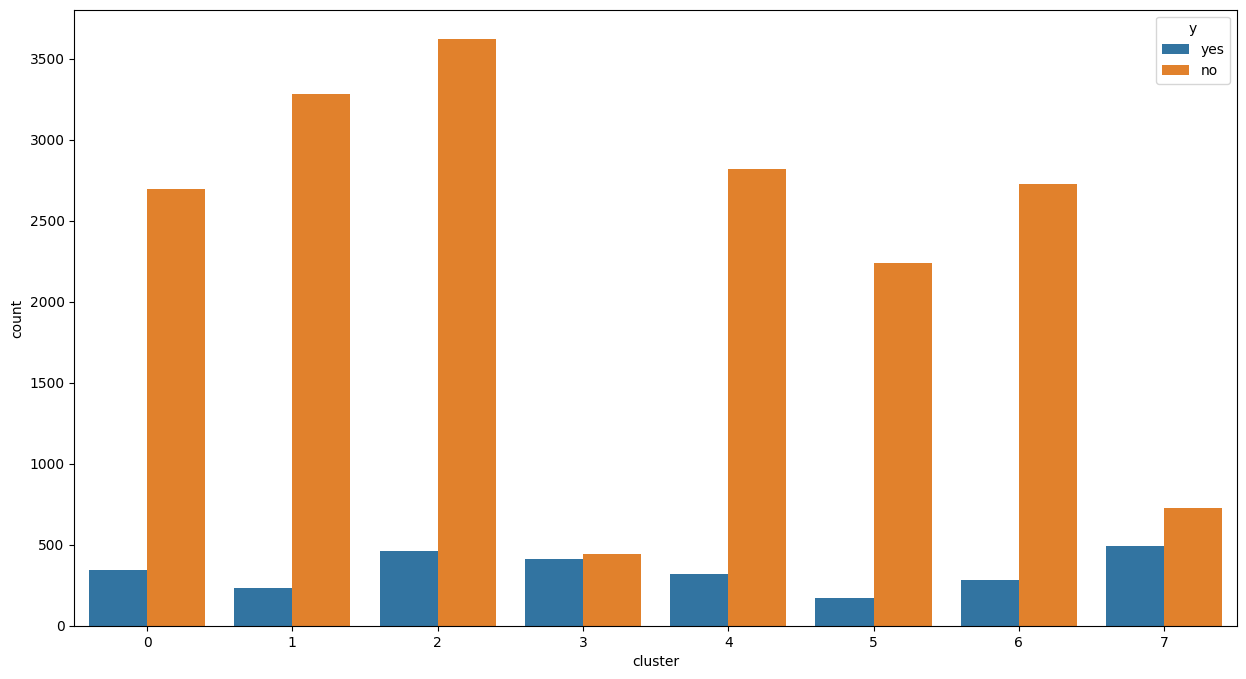

In [ ]:
con = (cluster_data['campaign']=='1')
plt.figure(figsize=(15,8))
ax = sns.countplot(x="cluster", hue="y", data=cluster_data)

<Axes: xlabel='cluster', ylabel='cons.conf.idx'>

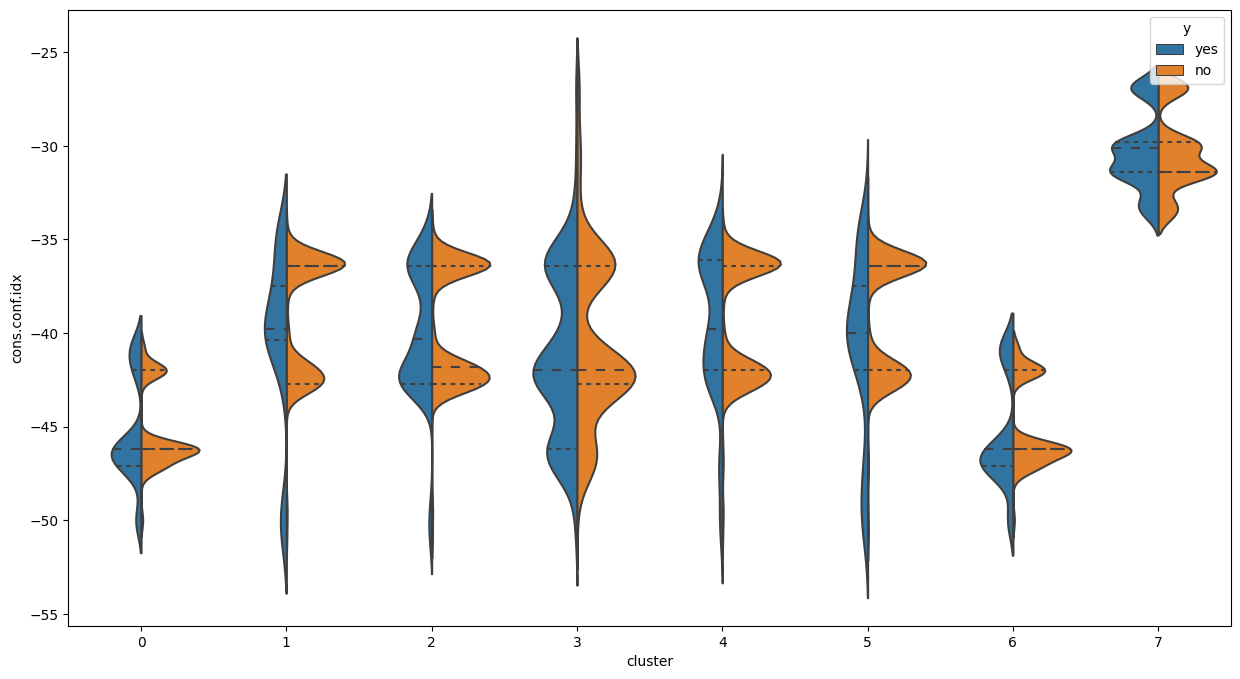

In [ ]:
plt.figure(figsize=(15,8))
sns.violinplot(data=cluster_data, x="cluster", y="cons.conf.idx",hue='y',split=True, inner="quart")

<Axes: xlabel='cluster', ylabel='cons.price.idx'>

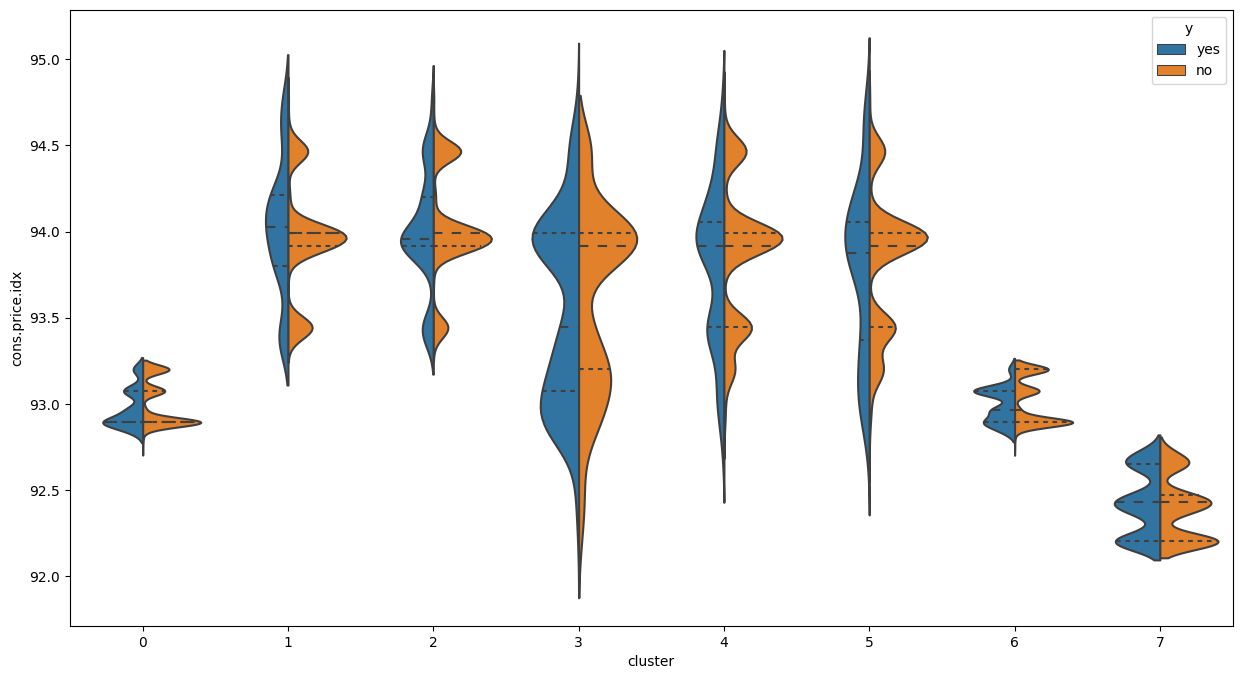

In [ ]:
plt.figure(figsize=(15,8))
sns.violinplot(data=cluster_data, x="cluster", y="cons.price.idx",hue='y',split=True, inner="quart")

<Axes: xlabel='cluster', ylabel='age'>

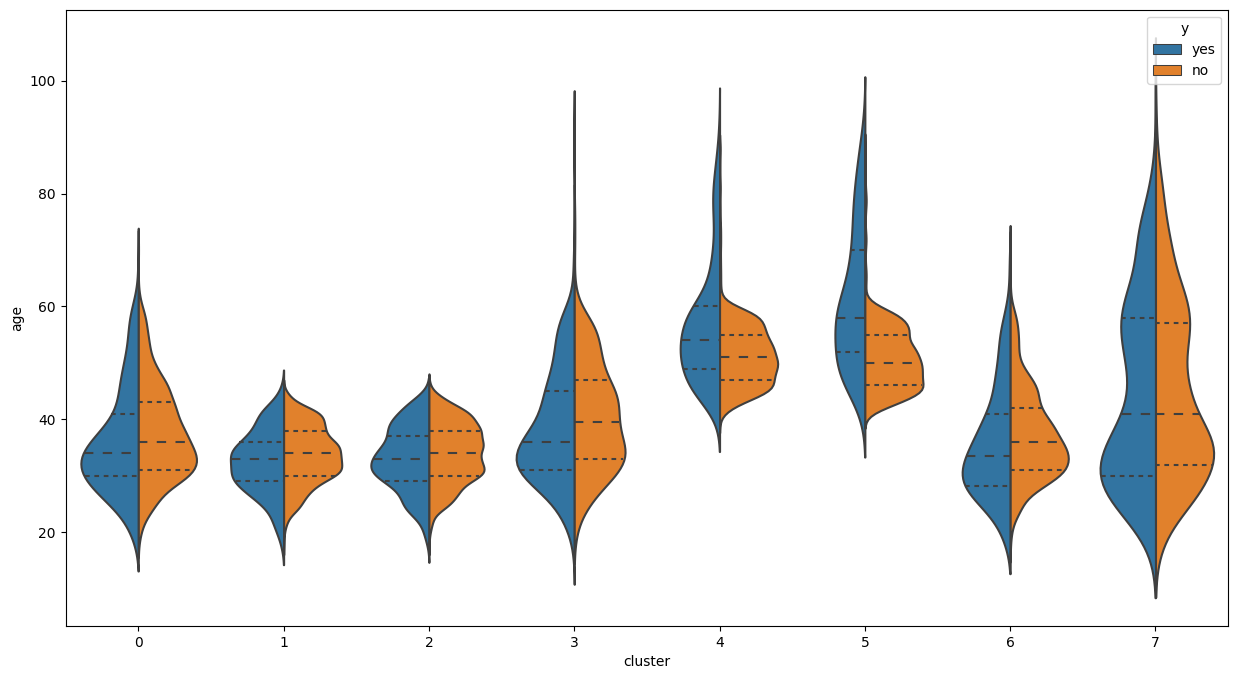

In [ ]:
plt.figure(figsize=(15,8))
sns.violinplot(data=cluster_data, x="cluster", y="age",hue='y',split=True, inner="quart")

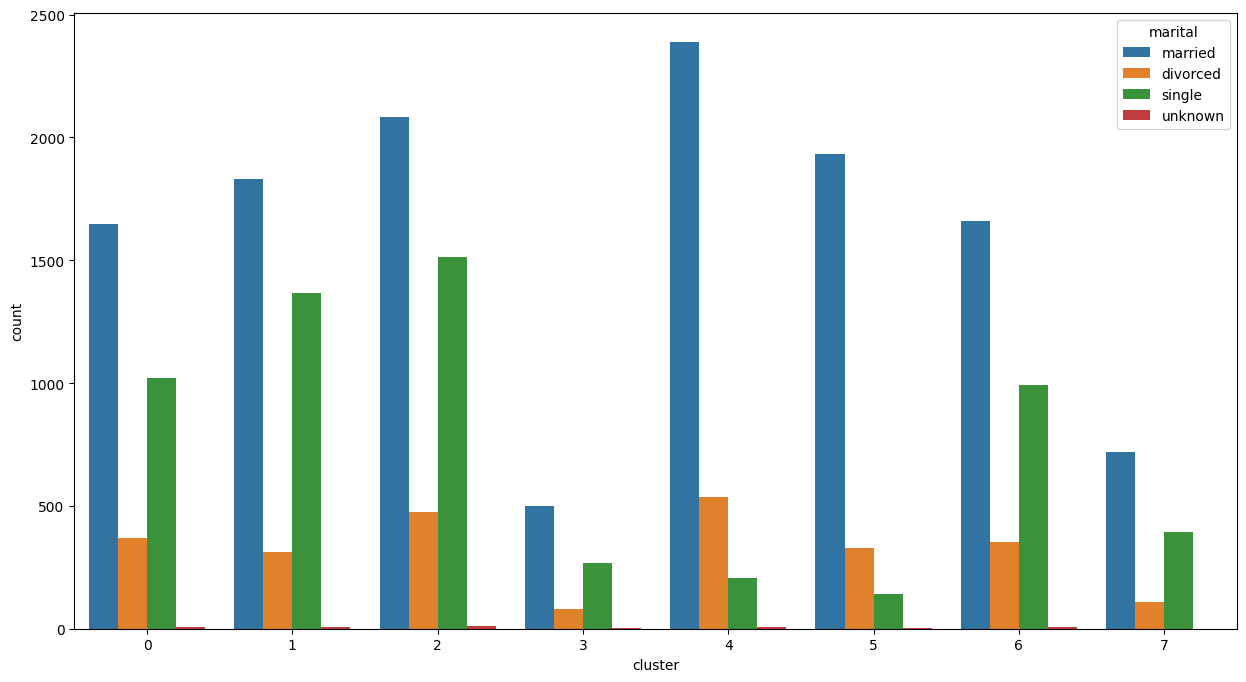

In [ ]:
plt.figure(figsize=(15,8))
ax = sns.countplot(x="cluster", hue="marital", data=cluster_data)

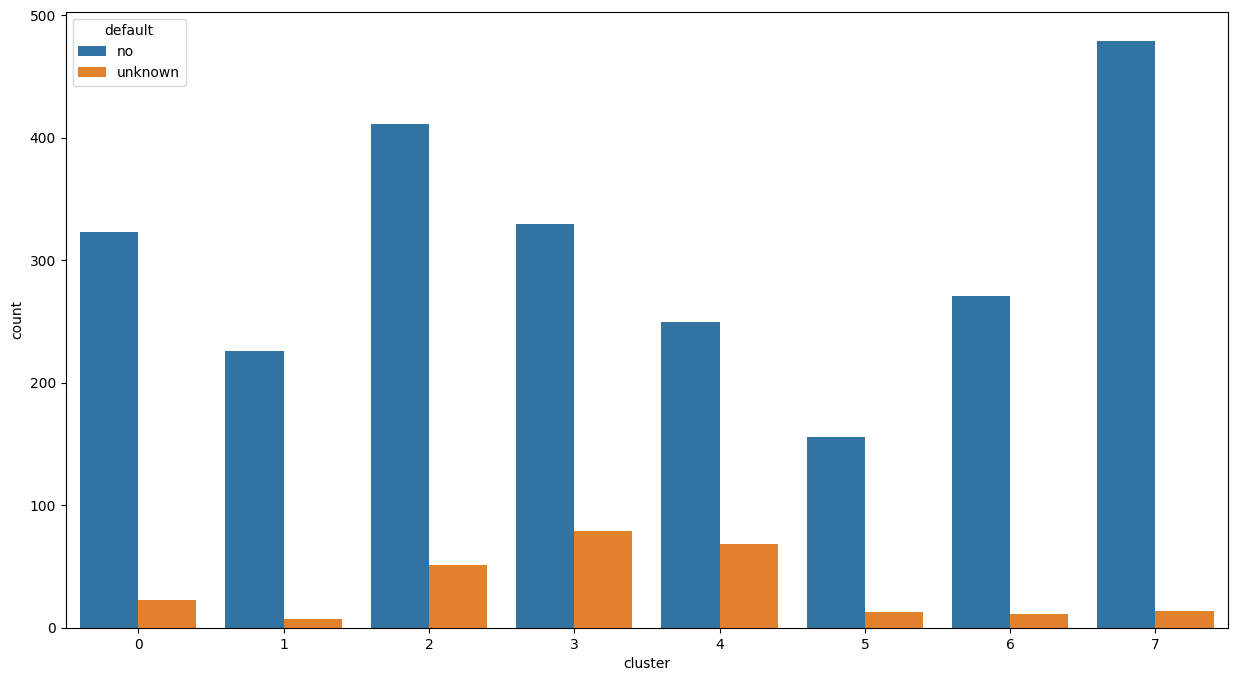

In [ ]:
plt.figure(figsize=(15,8))
# ax = sns.countplot(x="cluster", hue="housing", data=sample_customer)
ax = sns.countplot(x="cluster", hue="default", data=cluster_data.loc[(cluster_data['y']=='yes')])

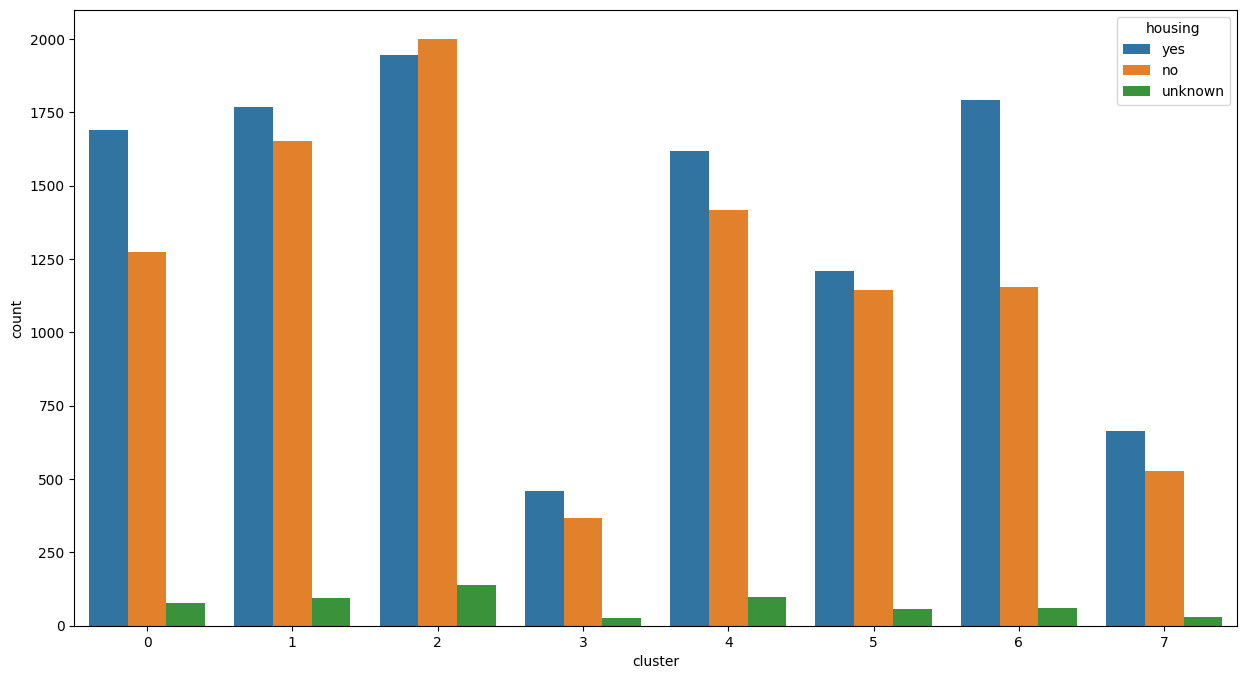

In [ ]:
plt.figure(figsize=(15,8))
ax = sns.countplot(x="cluster", hue="housing", data=cluster_data)

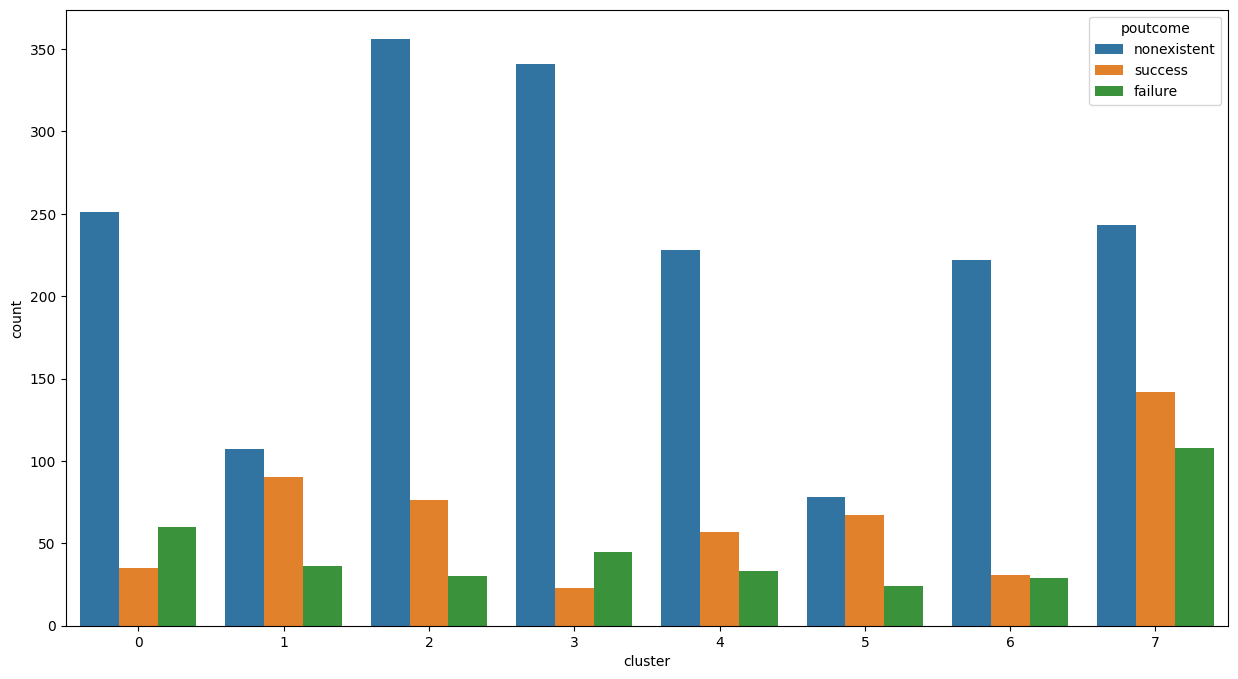

In [ ]:
plt.figure(figsize=(15,8))
ax = sns.countplot(x="cluster", hue="poutcome", data=cluster_data.loc[(cluster_data['y']=='yes')])